DATA TRANSFORMATION
--------------------

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


billing = pd.read_excel("1_Billing.xlsx")
billing.to_csv("1_Billing.csv", index=False)

resource = pd.read_excel("2_Resource_Inventory.xlsx")
resource.to_csv("2_Resource.csv", index=False)

incidents = pd.read_excel("3_Incidents.xlsx")
incidents.to_csv("3_Incidents.csv", index=False)

tickets = pd.read_excel("4_Support_Tickets.xlsx")
tickets.to_csv("4_Support_Tickets.csv", index=False)

finance = pd.read_excel("5_Customer_Finance.xlsx")
finance.to_csv("5_Customer_Finance.csv", index=False)

security = pd.read_excel("6_Security_Logs.xlsx")
security.to_csv("6_Security_Logs.csv", index=False)




plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

TC 1 : Daily and monthly cost/usage cubes (service, SKU, region).
------------------------------------------------------------------

In [4]:
# Convert timestamps to datetime objects
billing["TS"] = pd.to_datetime(billing["TS"])

In [5]:
billing["Date"] = billing["TS"].dt.date

billing["Month"] = billing["TS"].dt.to_period("M").astype(str)

In [6]:
billing = billing.merge(
    resource[["Resource_ID", "Region"]],
    on="Resource_ID",
    how="left"
)

In [7]:
# Daily cost cube and monthly cost cube
daily_cost_cube = (
    billing
    .groupby(
        ["Date","Service","SKU","Region"],
        as_index=False
    )
    .agg(
        Daily_Cost=("Cost","sum"),
        Daily_Usage=("Usage","sum")
    )
)

monthly_cost_cube = (
    billing
    .groupby(
        ["Month","Service","SKU","Region"],
        as_index=False
    )
    .agg(
        Monthly_Cost=("Cost","sum"),
        Monthly_Usage=("Usage","sum")
    )
)



print(daily_cost_cube.head())

print(monthly_cost_cube.head())


         Date  Service    SKU      Region Daily_Cost  Daily_Usage
0  2026-01-01  Compute  SKU10  ap-south-1    2249.84        28123
1  2026-01-01  Compute  SKU15   eu-west-1    3849.52        48119
2  2026-01-01  Compute   SKU4  ap-south-1       74.8          935
3  2026-01-01  Compute   SKU8   us-east-1     238.88         2986
4  2026-01-01  Network  SKU20   eu-west-1    2149.76        26872
     Month  Service    SKU      Region Monthly_Cost  Monthly_Usage
0  2026-01  Compute   SKU1  ap-south-1      3087.44          38593
1  2026-01  Compute  SKU10  ap-south-1      5578.64          69733
2  2026-01  Compute  SKU10   eu-west-1      3127.68          39096
3  2026-01  Compute  SKU10   us-east-1      3205.28          40066
4  2026-01  Compute  SKU11   us-east-1      3343.44          41793


In [8]:
# Converting cost to numeric values for analysis
billing["Cost"] = ( billing["Cost"].astype(str).str.replace("$", "", regex=False).str.replace(",", "", regex=False))

billing["Cost"] = pd.to_numeric( billing["Cost"],errors="coerce")

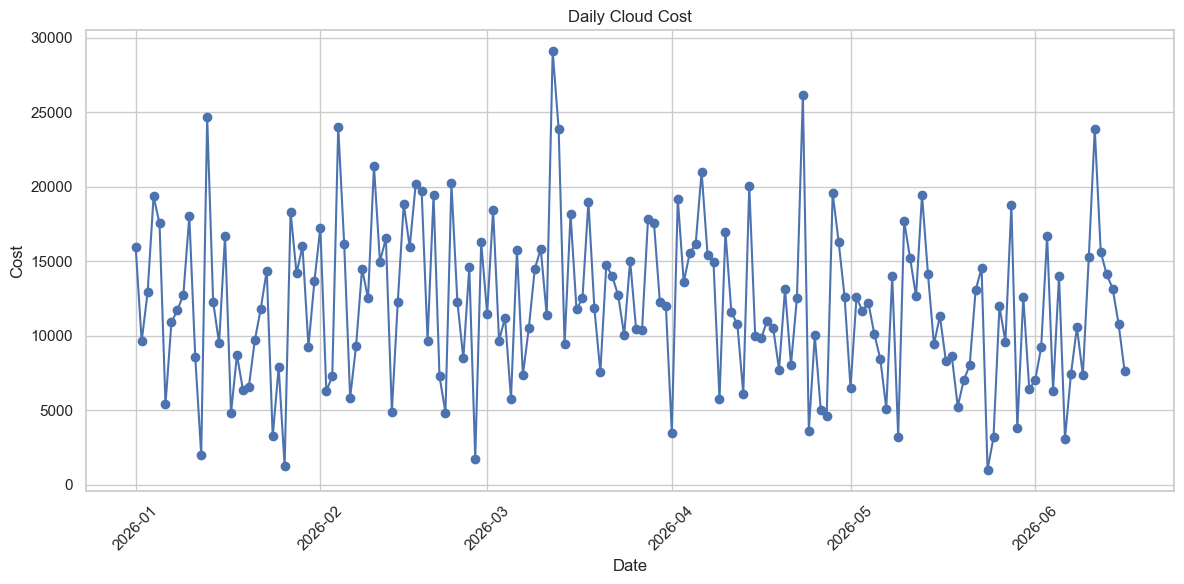

In [9]:
# Daily cost plot

daily_plot = ( billing.groupby("Date")["Cost"].sum() )

plt.figure(figsize=(12,6))

plt.plot( daily_plot.index,daily_plot.values,marker="o" )

plt.title("Daily Cloud Cost")

plt.xlabel("Date")

plt.ylabel("Cost")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [10]:
# Add monthly cost plot
billing["Month"] = pd.to_datetime(billing["TS"]).dt.to_period("M").astype(str)

In [11]:
# Converting cost to numeric values for analysis
billing["Cost"] = ( billing["Cost"].astype(str).str.replace("$", "", regex=False).str.replace(",", "", regex=False))

billing["Cost"] = pd.to_numeric( billing["Cost"],errors="coerce")

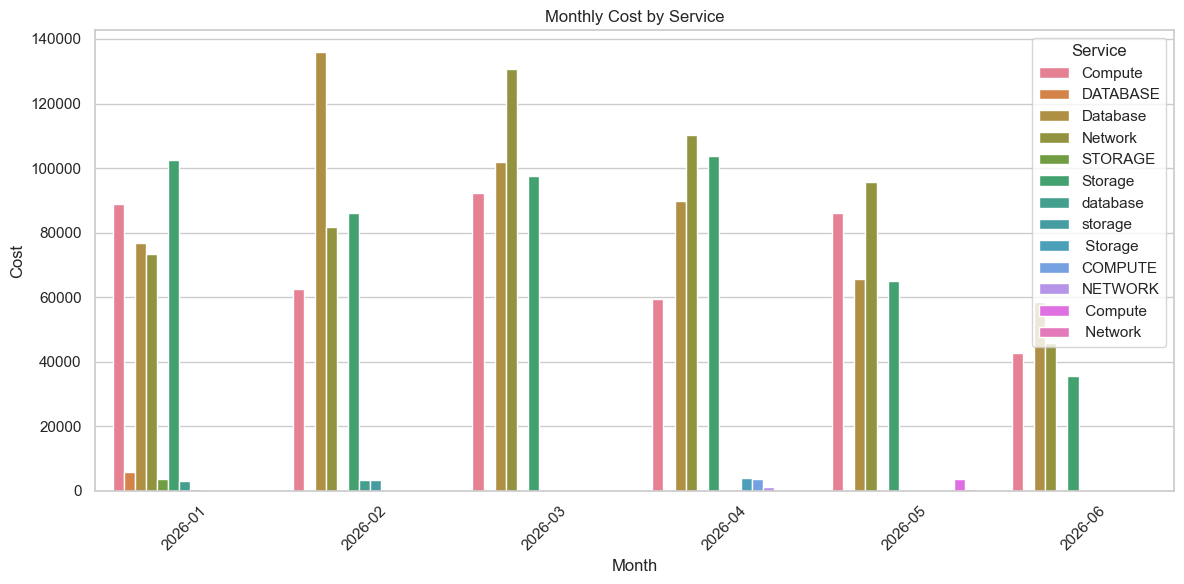

In [12]:
# MOnthly cost plot
monthly_service = ( billing.groupby( ["Month","Service"] )["Cost"].sum().reset_index())

plt.figure(figsize=(12,6))

sns.barplot( data=monthly_service,x="Month",y="Cost",hue="Service")

plt.title("Monthly Cost by Service")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

TC : 3  RI/Savings Plan utilization and coverage metrics.
-----------------------------------------------------------

In [13]:
np.random.seed(42)

billing["Purchase_Option"] = np.random.choice(
    ["On-Demand","Reserved","Savings Plan"],
    size=len(billing),
    p=[0.55,0.25,0.20]
)

In [14]:
billing["Covered_Usage"] = np.where(
    billing["Purchase_Option"]=="On-Demand",
    0,
    billing["Usage"]
)

ri_usage = billing.loc[
    billing["Purchase_Option"]=="Reserved",
    "Usage"
].sum()

sp_usage = billing.loc[
    billing["Purchase_Option"]=="Savings Plan",
    "Usage"
].sum()

total_commitment = ri_usage + sp_usage

In [15]:
# Coverage
total_usage = billing["Usage"].sum()

coverage = ( total_commitment / total_usage) * 100

print(f"Coverage = {coverage:.2f}%")

Coverage = 44.08%


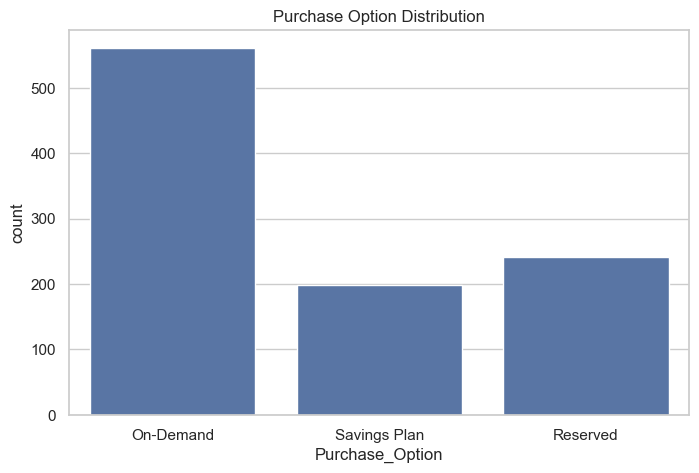

In [16]:
# Vsualizing the coverage.
plt.figure(figsize=(8,5))

sns.countplot( data=billing,x="Purchase_Option")

plt.title("Purchase Option Distribution")

plt.show()

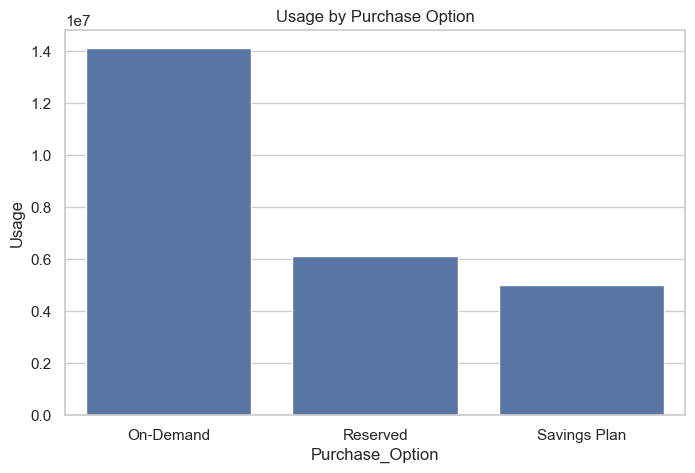

In [17]:
usage = billing.groupby( "Purchase_Option")["Usage"].sum().reset_index()

plt.figure(figsize=(8,5))

sns.barplot( data=usage, x="Purchase_Option", y="Usage" )

plt.title("Usage by Purchase Option")

plt.show()

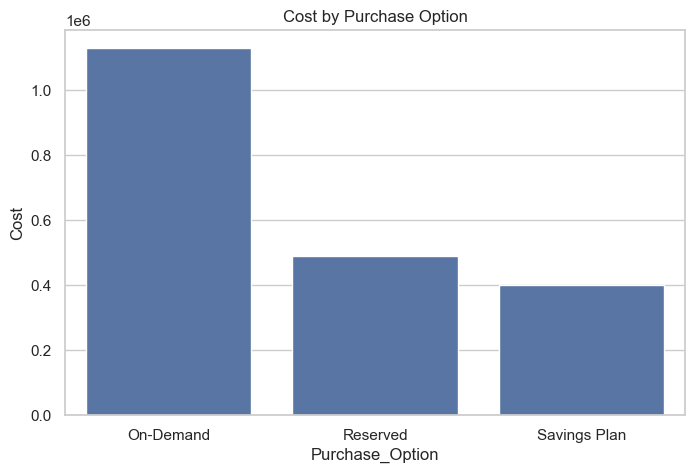

In [18]:
cost = billing.groupby( "Purchase_Option" )["Cost"].sum().reset_index()

plt.figure(figsize=(8,5))

sns.barplot( data=cost, x="Purchase_Option", y="Cost" )

plt.title("Cost by Purchase Option")

plt.show()

TC : 4  Idle/rightsizing recommendations features.
---------------------------------------------------

In [19]:
resource_cost = resource.merge( billing[["Resource_ID", "Cost", "Usage"]],on="Resource_ID",how="left")

In [20]:
required_columns = [ "CPU_Utilization","Memory_Utilization"]

if all(col in resource_cost.columns for col in required_columns):
    print("Utilization metrics available.")
else:
    print("Utilization metrics not available.")

Utilization metrics available.


In [21]:
# Rightsizing logic

if all(col in resource_cost.columns for col in required_columns):

    conditions = [
        resource_cost["CPU_Utilization"] < 5,
        resource_cost["CPU_Utilization"].between(5, 20),
        resource_cost["CPU_Utilization"] >= 20
    ]

    recommendations = [ "Stop / Terminate","Downsize Instance","Keep Current Size"]

    resource_cost["Rightsizing_Recommendation"] = np.select(
        conditions,
        recommendations,
        default="Review"
    )

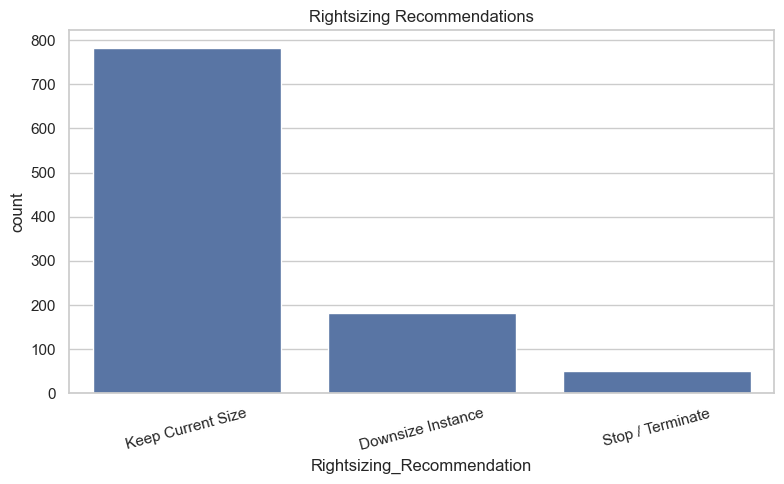

In [22]:
# visualizing the rightsizing.
if "Rightsizing_Recommendation" in resource_cost.columns:

    plt.figure(figsize=(8,5))

    sns.countplot(
        data=resource_cost,
        x="Rightsizing_Recommendation"
    )

    plt.title("Rightsizing Recommendations")

    plt.xticks(rotation=15)

    plt.tight_layout()

    plt.show()

Tc : 5 SRE KPIs: SLO/SLA attainment, error budgets.
----------------------------------------------------

In [23]:
print(incidents.columns)

Index(['Incident_ID', 'Resource_ID', 'Open_Time', 'Close_Time', 'Severity',
       'Status', 'Error_Count', 'SLA_Status'],
      dtype='object')


In [24]:
incidents["Open_Time"] = pd.to_datetime(incidents["Open_Time"])
incidents["Close_Time"] = pd.to_datetime(incidents["Close_Time"])

In [25]:
# Calculate Downtime
incidents["Downtime_Minutes"] = ( incidents["Close_Time"] - incidents["Open_Time"] ).dt.total_seconds() / 60

# Total Downtime 
total_downtime = incidents["Downtime_Minutes"].sum()

print("Total Downtime:", total_downtime)

Total Downtime: 12016.0


In [26]:
TOTAL_MINUTES = 43200               # one month comntains 43200 minutes

availability = ( (TOTAL_MINUTES - total_downtime) / TOTAL_MINUTES ) * 100

print(f"Availability = {availability:.2f}%")

Availability = 72.19%


In [27]:
# SLA Attainment 
SLA_TARGET = 99.9

sla_status = ( "Met" if availability >= SLA_TARGET
                     else "Not Met" )

print("SLA:", sla_status)

SLA: Not Met


In [28]:
# SLO Attainment
SLO_TARGET = 99.5

slo_status = ( "Met" if availability >= SLO_TARGET
                        else "Not Met" )

print("SLO:", slo_status)

SLO: Not Met


In [29]:
# Error Budget
error_budget = TOTAL_MINUTES * (1 - SLA_TARGET / 100)

remaining_budget = error_budget - total_downtime

print("Remaining Error Budget:", remaining_budget)

Remaining Error Budget: -11972.800000000005


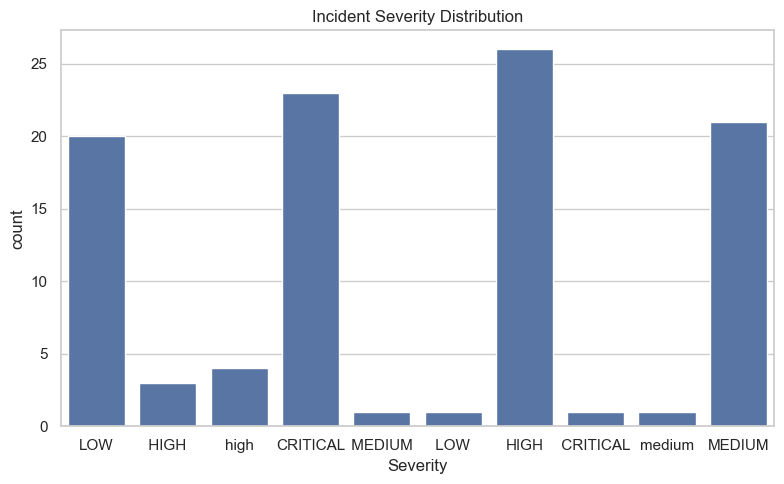

In [30]:
# Incident Severity Analysis
plt.figure(figsize=(8,5))

sns.countplot( data=incidents, x="Severity" )

plt.title("Incident Severity Distribution")

plt.tight_layout()

plt.show()

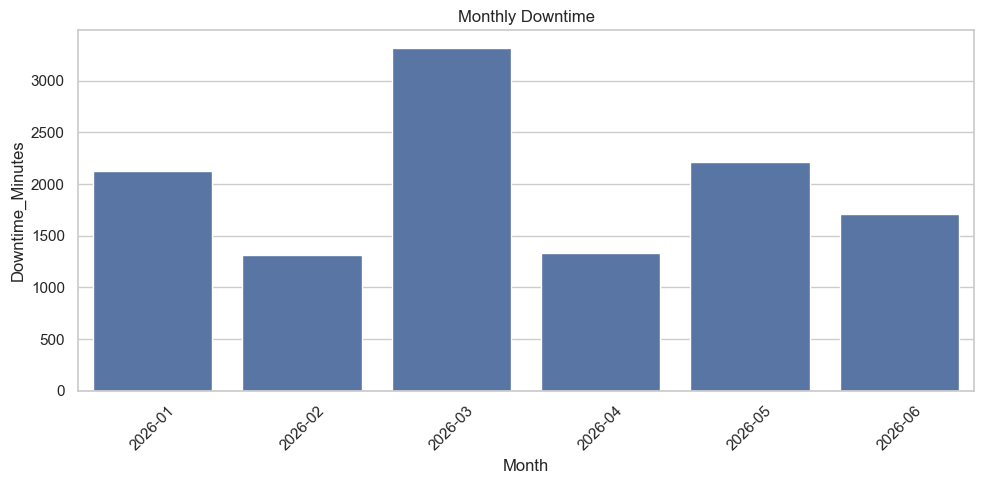

In [31]:
# Monthly Downtime
incidents["Month"] = ( incidents["Open_Time"].dt.to_period("M").astype(str) )

monthly = ( incidents.groupby("Month")["Downtime_Minutes"].sum().reset_index() )

plt.figure(figsize=(10,5))

sns.barplot( data=monthly, x="Month", y="Downtime_Minutes" )

plt.title("Monthly Downtime")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

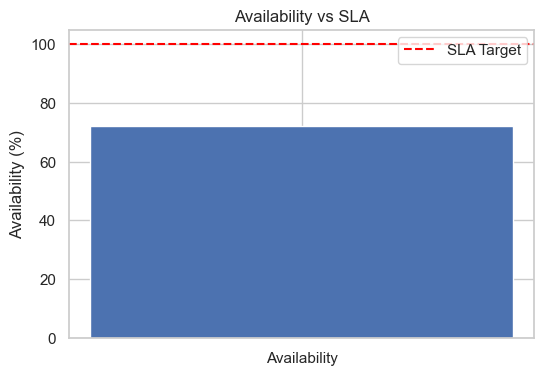

In [32]:
# SLA Gauge
plt.figure(figsize=(6,4))

plt.bar( ["Availability"], [availability] )

plt.axhline( SLA_TARGET, color="red", linestyle="--", label="SLA Target" )

plt.ylabel("Availability (%)")

plt.title("Availability vs SLA")

plt.legend()

plt.show()

In [33]:
# KPI Summmery

kpi = pd.DataFrame({
    "Metric": [
        "Availability",
        "SLA Target",
        "SLO Target",
        "Total Downtime (Minutes)",
        "Remaining Error Budget"
    ],
    "Value": [
        round(availability, 2),
        SLA_TARGET,
        SLO_TARGET,
        round(total_downtime, 2),
        round(remaining_budget, 2)
    ]
})

print(kpi)

                     Metric     Value
0              Availability     72.19
1                SLA Target     99.90
2                SLO Target     99.50
3  Total Downtime (Minutes)  12016.00
4    Remaining Error Budget -11972.80


TC : 6  Incident MTTA/MTTR metrics and trend.
-----------------------------------------------

In [34]:
# Converting to datetime otherwise it will show type error while using it into other datatype
incidents["Open_Time"] = pd.to_datetime(incidents["Open_Time"])
incidents["Close_Time"] = pd.to_datetime(incidents["Close_Time"])

In [35]:
# Normalize Severity And Status
incidents["Severity"] = ( incidents["Severity"].str.strip().str.title() )

incidents["Status"] = ( incidents["Status"].str.strip().str.upper() )

In [36]:
# Calculating the resolution time.
incidents["MTTR_Minutes"] = ( incidents["Close_Time"] - incidents["Open_Time"] ).dt.total_seconds() / 60

In [37]:
# Overall MTTR
overall_mttr = incidents["MTTR_Minutes"].mean()

print(f"Overall MTTR : {overall_mttr:.2f} Minutes")

Overall MTTR : 121.37 Minutes


In [38]:
# MTTR by severity
severity_mttr = ( incidents.groupby("Severity", as_index=False).agg( Average_MTTR=("MTTR_Minutes", "mean"),
        Incident_Count=("Incident_ID", "count") ) )

print(severity_mttr)

   Severity  Average_MTTR  Incident_Count
0  Critical    106.750000              24
1      High    129.500000              33
2       Low    131.650000              21
3    Medium    116.391304              23


In [39]:
# Monthly MTTR Trend
incidents["Month"] = ( incidents["Open_Time"].dt.to_period("M").astype(str) )

monthly_mttr = ( incidents.groupby("Month", as_index=False).agg( Average_MTTR=("MTTR_Minutes", "mean")))

print(monthly_mttr)

     Month  Average_MTTR
0  2026-01    117.944444
1  2026-02    101.384615
2  2026-03    151.000000
3  2026-04     95.357143
4  2026-05    122.833333
5  2026-06    121.928571


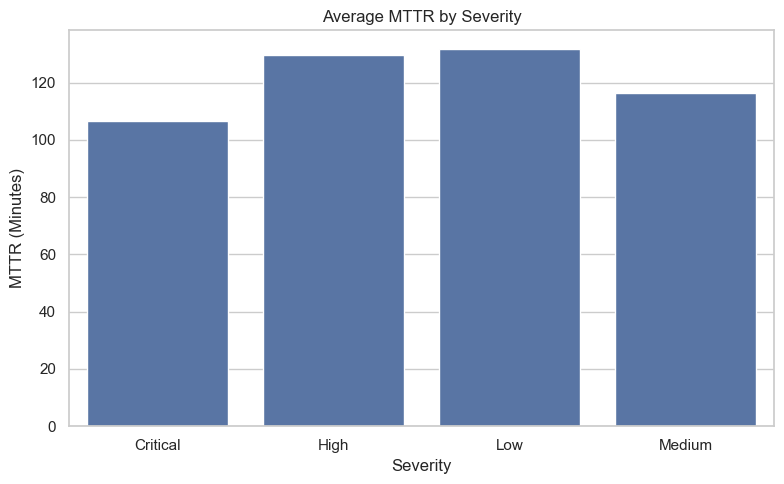

In [40]:
# Visualisation
plt.figure(figsize=(8,5))

sns.barplot( data=severity_mttr, x="Severity", y="Average_MTTR" )

plt.title("Average MTTR by Severity")

plt.xlabel("Severity")

plt.ylabel("MTTR (Minutes)")

plt.tight_layout()

plt.show()

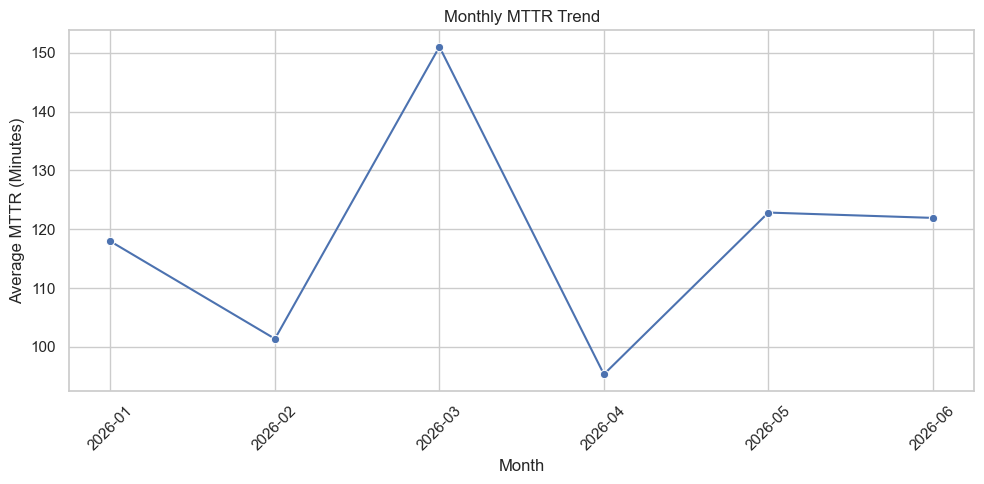

In [41]:
# Monthly MTTR Trend
plt.figure(figsize=(10,5))

sns.lineplot( data=monthly_mttr, x="Month", y="Average_MTTR", marker="o" )

plt.title("Monthly MTTR Trend")

plt.xlabel("Month")

plt.ylabel("Average MTTR (Minutes)")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

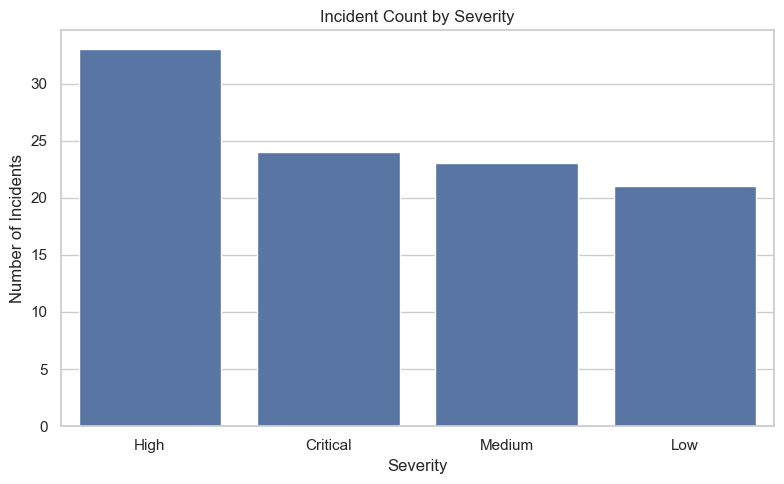

In [42]:
# Incident Count by Severity
plt.figure(figsize=(8,5))

sns.countplot( data=incidents, x="Severity", order=incidents["Severity"].value_counts().index )

plt.title("Incident Count by Severity")

plt.xlabel("Severity")

plt.ylabel("Number of Incidents")

plt.tight_layout()

plt.show()

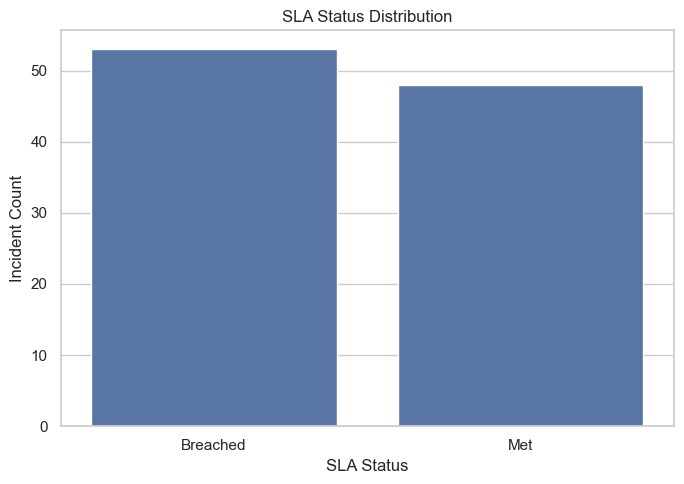

In [43]:
# SLA Status Distribution
plt.figure(figsize=(7,5))

sns.countplot( data=incidents, x="SLA_Status" )

plt.title("SLA Status Distribution")

plt.xlabel("SLA Status")

plt.ylabel("Incident Count")

plt.tight_layout()

plt.show()

TC : 7 Anomaly detection features for cost spikes.
---------------------------------------------------

In [44]:
billing["TS"] = pd.to_datetime(billing["TS"])

In [45]:
billing["Date"] = billing["TS"].dt.date

billing["Month"] = billing["TS"].dt.to_period("M").astype(str)

billing["Day"] = billing["TS"].dt.day

billing["Hour"] = billing["TS"].dt.hour

In [46]:
# Daily cost per account 
daily_cost = ( billing.groupby(["Account", "Date"], as_index=False).agg(Daily_Cost=("Cost", "sum"),
        Daily_Usage=("Usage", "sum") ) )

In [47]:
print(daily_cost["Daily_Cost"].dtype)

float64


In [48]:
# Removiing the symbol to avoid error
daily_cost["Daily_Cost"] = (
    daily_cost["Daily_Cost"].astype(str).str.replace("$", "", regex=False).str.replace(",", "", regex=False)
)

daily_cost["Daily_Cost"] = pd.to_numeric( daily_cost["Daily_Cost"], errors="coerce")

In [49]:
daily_cost = daily_cost.sort_values(["Account", "Date"])

daily_cost["Rolling_Avg_Cost"] = (
    daily_cost
    .groupby("Account")["Daily_Cost"]
    .transform(lambda x: x.rolling(7, min_periods=1).mean())
)

# Daily cost Spike

daily_cost["Cost_Spike_%"] = (
    ( daily_cost["Daily_Cost"] - daily_cost["Rolling_Avg_Cost"] ) / daily_cost["Rolling_Avg_Cost"] ) * 100

# Cost Z-Score
daily_cost["Cost_ZScore"] = (
    daily_cost
    .groupby("Account")["Daily_Cost"]
    .transform( lambda x: (x - x.mean()) / x.std() ) )

In [50]:
# Cost Anomalies
daily_cost["Cost_Anomaly"] = np.where( daily_cost["Cost_ZScore"] > 3, "Spike", "Normal" )

# View Anomalies
cost_spikes = daily_cost[ daily_cost["Cost_Anomaly"] == "Spike"]

print(cost_spikes)

Empty DataFrame
Columns: [Account, Date, Daily_Cost, Daily_Usage, Rolling_Avg_Cost, Cost_Spike_%, Cost_ZScore, Cost_Anomaly]
Index: []


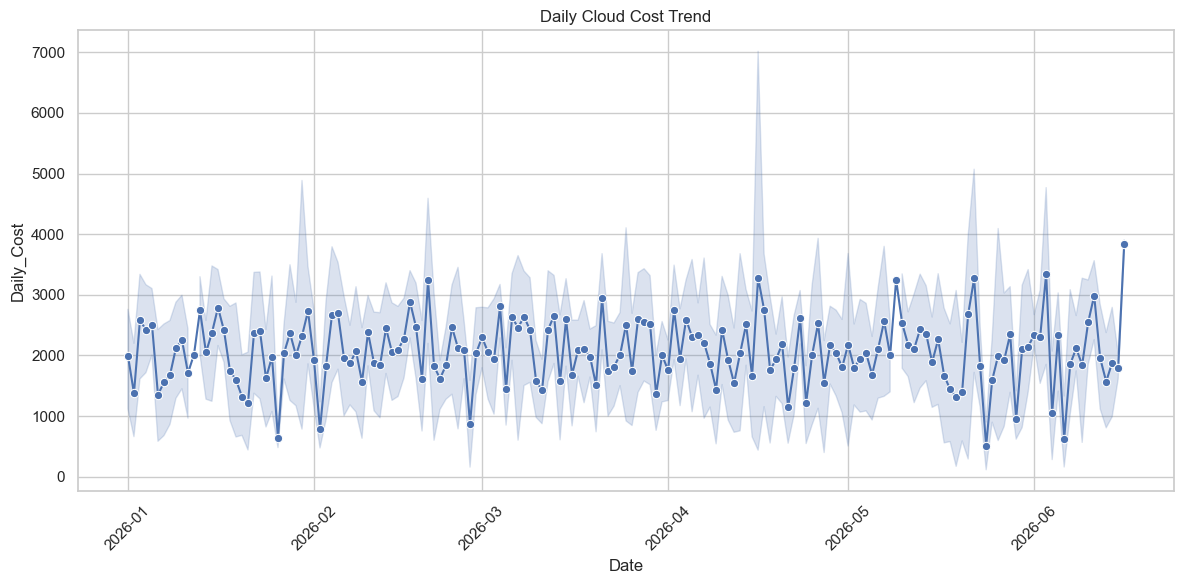

In [51]:
# Daily Cost Trend
plt.figure(figsize=(12,6))

sns.lineplot( data=daily_cost, x="Date", y="Daily_Cost", marker="o" )

plt.title("Daily Cloud Cost Trend")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

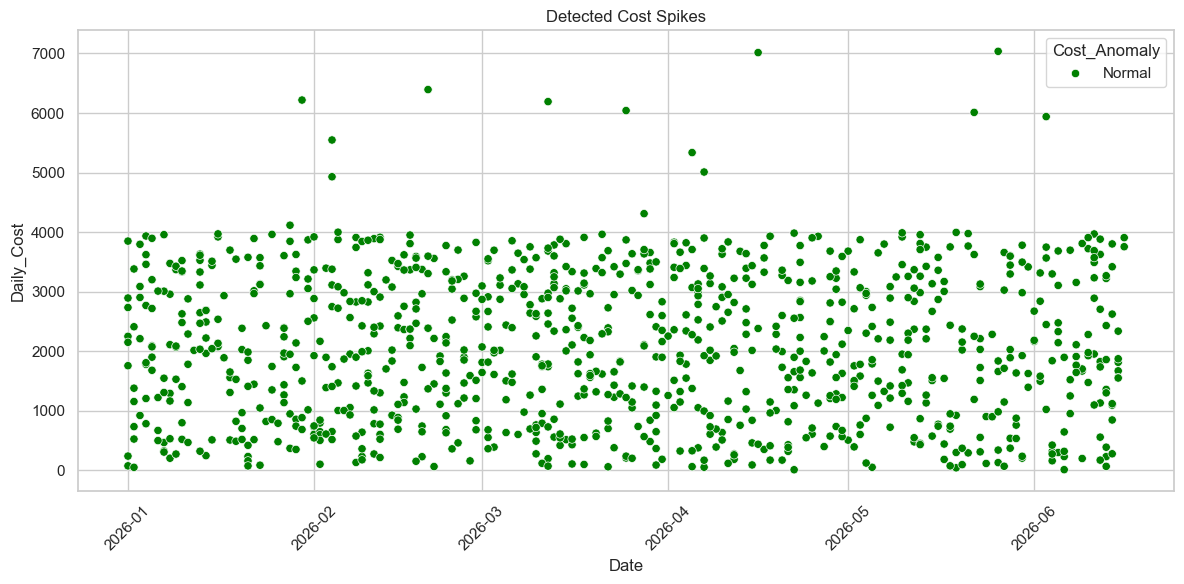

In [52]:
# Cost Spike detection
plt.figure(figsize=(12,6))

sns.scatterplot(
    data=daily_cost,
    x="Date",
    y="Daily_Cost",
    hue="Cost_Anomaly",
    palette={
        "Normal":"green",
        "Spike":"red"
    }
)

plt.title("Detected Cost Spikes")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

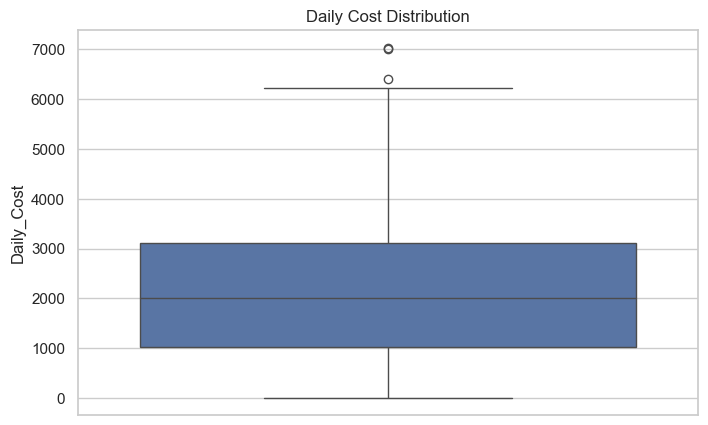

In [53]:
# Cost Detection
plt.figure(figsize=(8,5))

sns.boxplot( y=daily_cost["Daily_Cost"] )

plt.title("Daily Cost Distribution")

plt.show()

In [54]:
# Cleaning the cost column
billing["Cost"] = ( billing["Cost"].astype(str).str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
)

billing["Cost"] = pd.to_numeric(
    billing["Cost"],
    errors="coerce"
)

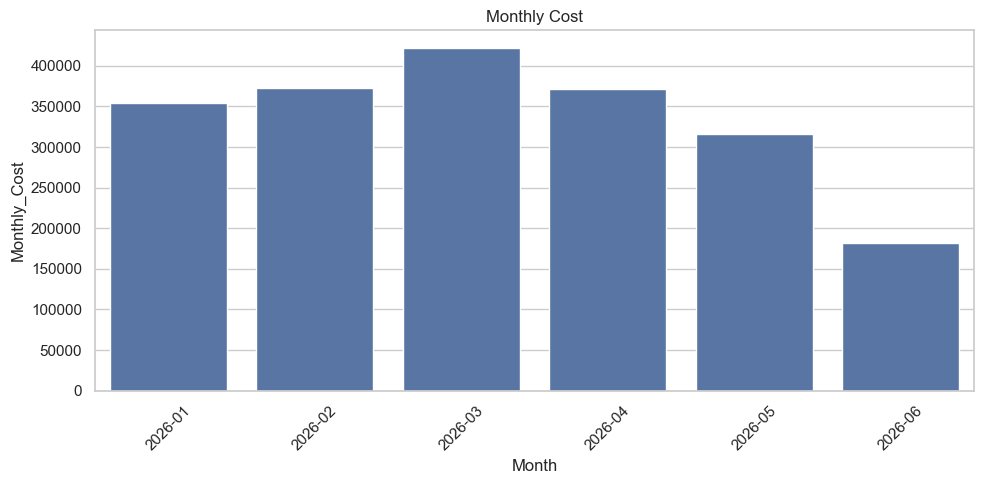

In [55]:
# Monthly Cost Trend
monthly = ( billing.groupby("Month", as_index=False).agg( Monthly_Cost=("Cost", "sum") ) )

plt.figure(figsize=(10,5))

sns.barplot(
    data=monthly,
    x="Month",
    y="Monthly_Cost"
)

plt.title("Monthly Cost")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

TC : 8 Unit cost (₹/vCPU‑hr, ₹/GB‑mo) normalization.
-----------------------------------------------------

In [56]:
# Clean merge keys
billing["Resource_ID"] = billing["Resource_ID"].astype(str).str.strip().str.upper()
billing["Account"] = billing["Account"].astype(str).str.strip().str.upper()

resource["Resource_ID"] = resource["Resource_ID"].astype(str).str.strip().str.upper()
resource["Account"] = resource["Account"].astype(str).str.strip().str.upper()

# Remove duplicate resources
resource = resource.drop_duplicates(subset=["Resource_ID", "Account"])

# Merge
billing_resource = billing.merge(
    resource,
    on=["Resource_ID", "Account"],
    how="left"
)

In [57]:
# Normalize Usage to Hours
billing_resource["Unit"] = billing_resource["Unit"].str.strip().str.lower()

unit_factor = {
    "sec": 1/3600,
    "min": 1/60,
    "hrs": 1,
    "hr": 1
}

billing_resource["Usage_Hours"] = (
    billing_resource["Usage"] *
    billing_resource["Unit"].map(unit_factor)
)

# Cost Per Hour
billing_resource["Cost_Per_Hour"] = np.where(
    billing_resource["Usage_Hours"] > 0,
    billing_resource["Cost"] / billing_resource["Usage_Hours"],
    np.nan
)

# Cost Per CPU Utilization
billing_resource["Cost_Per_CPU_Util"] = np.where(
    billing_resource["CPU_Utilization"] > 0,
    billing_resource["Cost"] / billing_resource["CPU_Utilization"],
    np.nan
)

# Cost Per Memory Utilization
billing_resource["Cost_Per_Memory_Util"] = np.where(
    billing_resource["Memory_Utilization"] > 0,
    billing_resource["Cost"] / billing_resource["Memory_Utilization"],
    np.nan
)

In [58]:
# Clean Service Names
billing_resource["Service"] = (
    billing_resource["Service"]
    .astype(str)
    .str.strip()
    .str.upper()
)

# Summary by Service
service_cost = (
    billing_resource
    .groupby("Service", as_index=False)
    .agg(
        Average_Cost=("Cost", "mean"),
        Average_Cost_Per_Hour=("Cost_Per_Hour", "mean"),
        Average_CPU_Cost=("Cost_Per_CPU_Util", "mean"),
        Average_Memory_Cost=("Cost_Per_Memory_Util", "mean")
    )
    .sort_values("Average_Cost", ascending=False)
)

print(service_cost)


    Service  Average_Cost  Average_Cost_Per_Hour  Average_CPU_Cost  \
2   NETWORK   2113.795137             288.000000               NaN   
1  DATABASE   2103.505681             286.879689         197.32200   
0   COMPUTE   1951.875911             285.440711           4.09641   
3   STORAGE   1899.176970             288.000000               NaN   

   Average_Memory_Cost  
2                  NaN  
1            70.884028  
0             2.457846  
3                  NaN  


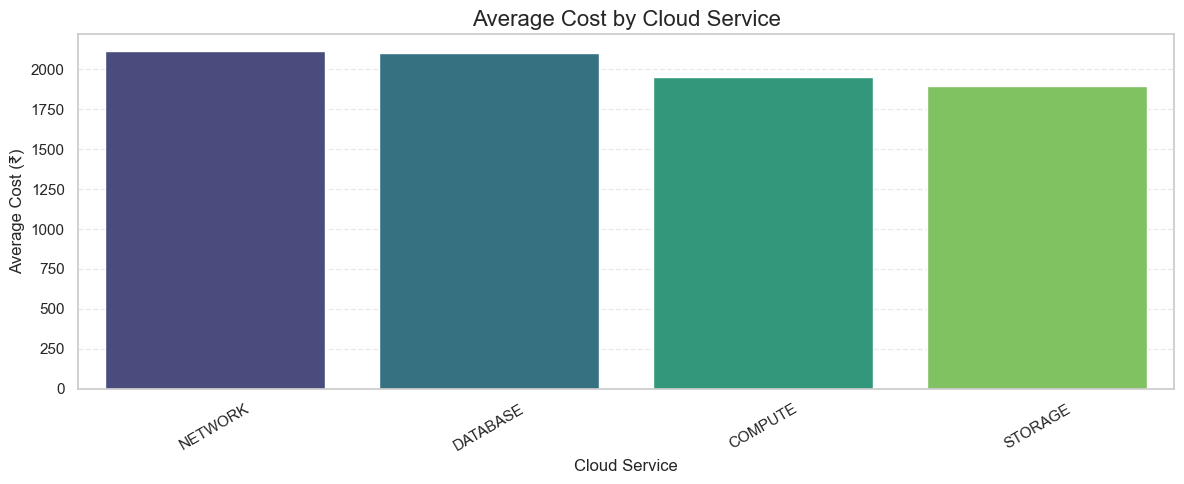

In [59]:
# Final Plot
plt.figure(figsize=(12,5))

sns.barplot(
    data=service_cost,
    x="Service",
    y="Average_Cost",
    hue="Service",
    palette="viridis",
    legend=False
)

plt.title("Average Cost by Cloud Service", fontsize=16)
plt.xlabel("Cloud Service", fontsize=12)
plt.ylabel("Average Cost (₹)", fontsize=12)

plt.xticks(rotation=30)
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

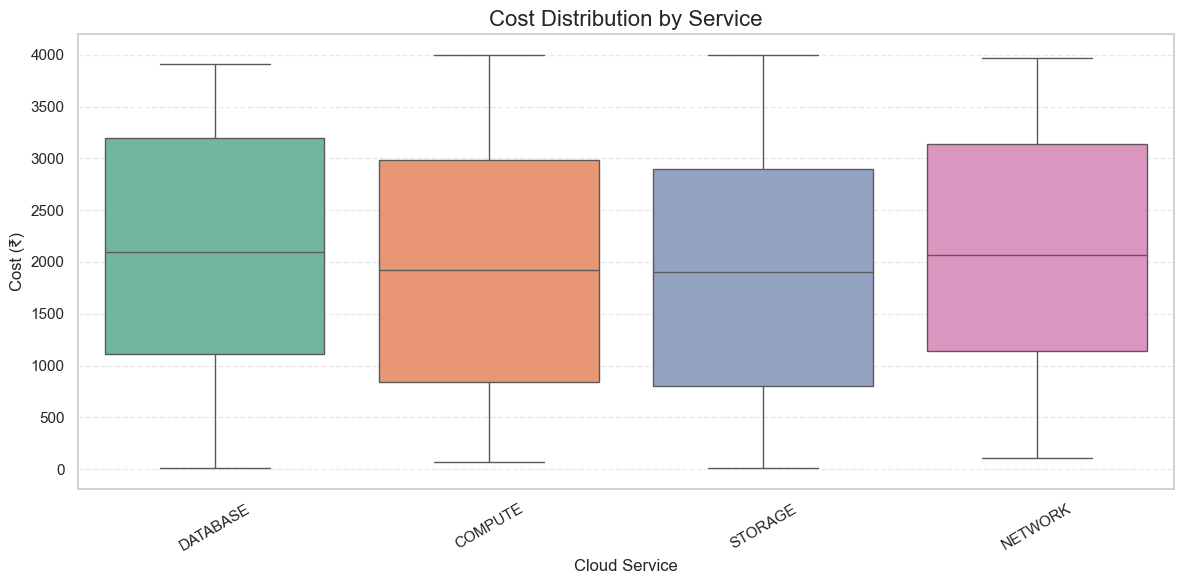

In [60]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=billing_resource,
    x="Service",
    y="Cost",
    hue="Service",
    palette="Set2",
    legend=False
)

plt.title("Cost Distribution by Service", fontsize=16)
plt.xlabel("Cloud Service", fontsize=12)
plt.ylabel("Cost (₹)", fontsize=12)

plt.xticks(rotation=30)
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

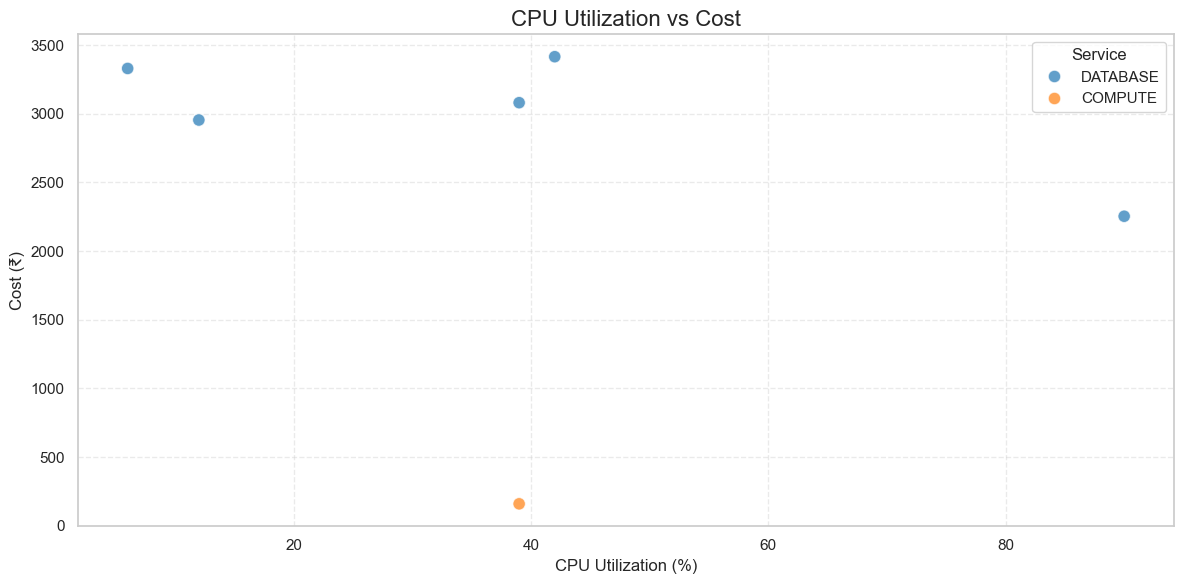

In [61]:
cpu_cost = billing_resource[
    ["CPU_Utilization", "Cost", "Service"]
].dropna()



plt.figure(figsize=(12,6))

sns.scatterplot(
    data=cpu_cost,
    x="CPU_Utilization",
    y="Cost",
    hue="Service",
    palette="tab10",
    alpha=0.7,
    s=80
)

plt.title("CPU Utilization vs Cost", fontsize=16)
plt.xlabel("CPU Utilization (%)", fontsize=12)
plt.ylabel("Cost (₹)", fontsize=12)

plt.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

TC : 9  Carbon footprint estimates per region and service.
-----------------------------------------------------------

In [67]:
# Merging the billing with resource
carbon = billing.merge( resource[ ["Resource_ID", "Region"] ], on="Resource_ID", how="left" )

# Merge carbin factor
carbon = carbon.merge( security[["Resource_ID", "Carbon_Factor"]],on="Resource_ID",how="left" )

In [68]:
# Calculate Carbon Emission
carbon["Carbon_Emission"] = ( carbon["Usage"] * carbon["Carbon_Factor"]).round(2)

# Region-wise Carbon Footprint
region_carbon = (carbon.groupby("Region_y", as_index=False).agg(
        Total_Carbon=("Carbon_Emission", "sum"),
        Total_Usage=("Usage", "sum")).sort_values("Total_Carbon", ascending=False))

print(region_carbon)

       Region_y  Total_Carbon  Total_Usage
7     us-east-1    6563369.00     18023447
6     eu-west-1    5631993.38     15415956
5    ap-south-1    4169567.91     12298868
0   ap-south-1      155310.87       369963
4     US-EAST-1     106324.50       391407
3     EU-WEST-1      99210.24       216768
2    AP-SOUTH-1      67501.47       184966
1    us-east-1       64967.24       140370


In [69]:
# Service wise carbon footprint
service_carbon = ( carbon.groupby("Service", as_index=False).agg(
        Total_Carbon=("Carbon_Emission", "sum"),
        Total_Cost=("Cost", "sum") ) )

print(service_carbon)

      Service  Total_Carbon  Total_Cost
0    Compute       11725.24     4598.08
1    Network        2486.03      537.52
2    Storage       26603.95     7703.44
3     COMPUTE      56568.96    10775.04
4     Compute    3331031.44   768125.60
5    DATABASE      49121.24     9742.32
6    Database    4592319.34  1023041.28
7     NETWORK       4727.16     1050.48
8     Network    4367692.44   983946.88
9     STORAGE          0.00     3474.88
10    Storage    4304867.43   925664.48
11   database      61606.20    13590.88
12    storage      49495.18    11088.72


In [70]:
# Clean Region and Service names
carbon["Region_y"] = ( carbon["Region_y"].astype(str).str.strip().str.upper())

carbon["Service"] = (carbon["Service"].astype(str).str.strip().str.upper())

# Region + Service Carbon Cube
carbon_cube = (carbon.groupby(["Region_y", "Service"], as_index=False).agg(
        Carbon_Emission=("Carbon_Emission", "sum"),
        Total_Cost=("Cost", "sum"),
        Total_Usage=("Usage", "sum")).sort_values("Carbon_Emission", ascending=False))

print(carbon_cube)

      Region_y   Service  Carbon_Emission  Total_Cost  Total_Usage
11   US-EAST-1   STORAGE       1829755.44   381935.04      4774188
5    EU-WEST-1  DATABASE       1817398.23   390697.84      4883723
8    US-EAST-1   COMPUTE       1685941.73   372929.52      4661619
10   US-EAST-1   NETWORK       1679025.83   368657.28      4608216
7    EU-WEST-1   STORAGE       1544227.24   334229.60      4177870
9    US-EAST-1  DATABASE       1539937.74   360896.08      4511201
6    EU-WEST-1   NETWORK       1424092.07   307180.40      3839755
1   AP-SOUTH-1  DATABASE       1345710.81   294780.56      3684757
2   AP-SOUTH-1   NETWORK       1271787.73   309697.20      3871215
3   AP-SOUTH-1   STORAGE       1006983.88   231766.88      2897086
4    EU-WEST-1   COMPUTE        945486.08   218510.08      2731376
0   AP-SOUTH-1   COMPUTE        767897.83   192059.12      2400739


In [71]:
# Clean Region and Service
carbon["Region_y"] = (carbon["Region_y"].astype(str).str.strip().str.upper())

carbon["Service"] = (carbon["Service"].astype(str).str.strip().str.upper())

# Remove Duplicate Records
carbon = carbon.drop_duplicates(subset=["Usage_ID"],keep="first")

# Create Carbon Cube
carbon_cube = (carbon.groupby(["Region_y", "Service"], as_index=False).agg(
        Total_Carbon=("Carbon_Emission", "sum"),
        Total_Cost=("Cost", "sum"),
        Total_Usage=("Usage", "sum")).sort_values(by=["Region_y", "Service"]))

print(carbon_cube)

      Region_y   Service  Total_Carbon  Total_Cost  Total_Usage
0   AP-SOUTH-1   COMPUTE     434350.23   123015.84      1537698
1   AP-SOUTH-1  DATABASE     639618.45   150817.76      1885222
2   AP-SOUTH-1   NETWORK     681453.60   184159.36      2301992
3   AP-SOUTH-1   STORAGE     570453.36   147899.12      1848739
4    EU-WEST-1   COMPUTE     448372.82   120919.20      1511490
5    EU-WEST-1  DATABASE     829541.73   191976.32      2399704
6    EU-WEST-1   NETWORK     708467.59   165051.76      2063147
7    EU-WEST-1   STORAGE     719139.48   176855.76      2210697
8    US-EAST-1   COMPUTE     826697.49   194691.68      2433646
9    US-EAST-1  DATABASE     738351.26   197806.88      2472586
10   US-EAST-1   NETWORK     806627.07   189806.64      2372583
11   US-EAST-1   STORAGE     821740.36   176627.84      2207848


C:\Users\KIIT\AppData\Local\Temp\ipykernel_11344\1253813917.py:18: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\KIIT\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


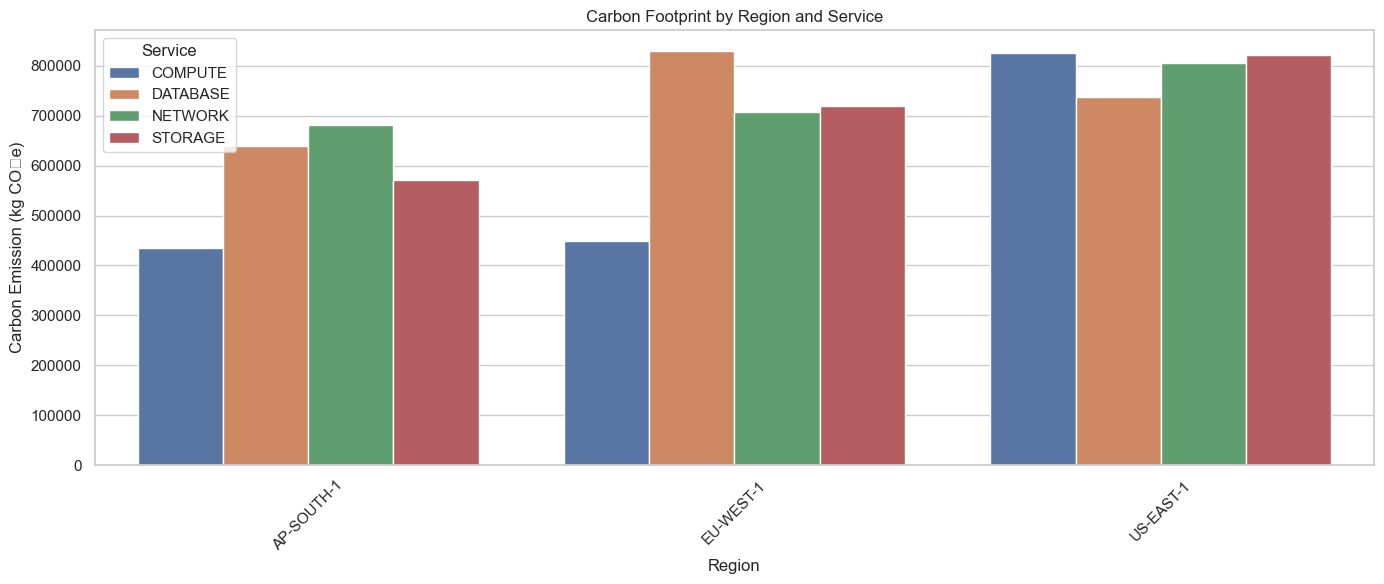

In [72]:
plt.figure(figsize=(14,6))

sns.barplot(
    data=carbon_cube,
    x="Region_y",
    y="Total_Carbon",
    hue="Service",
    estimator=sum,
    errorbar=None
)

plt.title("Carbon Footprint by Region and Service")
plt.xlabel("Region")
plt.ylabel("Carbon Emission (kg CO₂e)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [73]:
print(service_carbon)

      Service  Total_Carbon  Total_Cost
0    Compute       11725.24     4598.08
1    Network        2486.03      537.52
2    Storage       26603.95     7703.44
3     COMPUTE      56568.96    10775.04
4     Compute    3331031.44   768125.60
5    DATABASE      49121.24     9742.32
6    Database    4592319.34  1023041.28
7     NETWORK       4727.16     1050.48
8     Network    4367692.44   983946.88
9     STORAGE          0.00     3474.88
10    Storage    4304867.43   925664.48
11   database      61606.20    13590.88
12    storage      49495.18    11088.72


In [74]:
print("Total rows:", len(carbon))
print("Duplicate Usage_ID:", carbon["Usage_ID"].duplicated().sum())

Total rows: 1000
Duplicate Usage_ID: 0


In [75]:
service_carbon = (carbon.groupby("Service", as_index=False).agg(
        Total_Carbon=("Carbon_Emission", "sum"),
        Total_Cost=("Cost", "sum"),
        Total_Usage=("Usage", "sum")))

C:\Users\KIIT\AppData\Local\Temp\ipykernel_11344\2958971203.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\KIIT\AppData\Local\Temp\ipykernel_11344\2958971203.py:20: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\KIIT\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


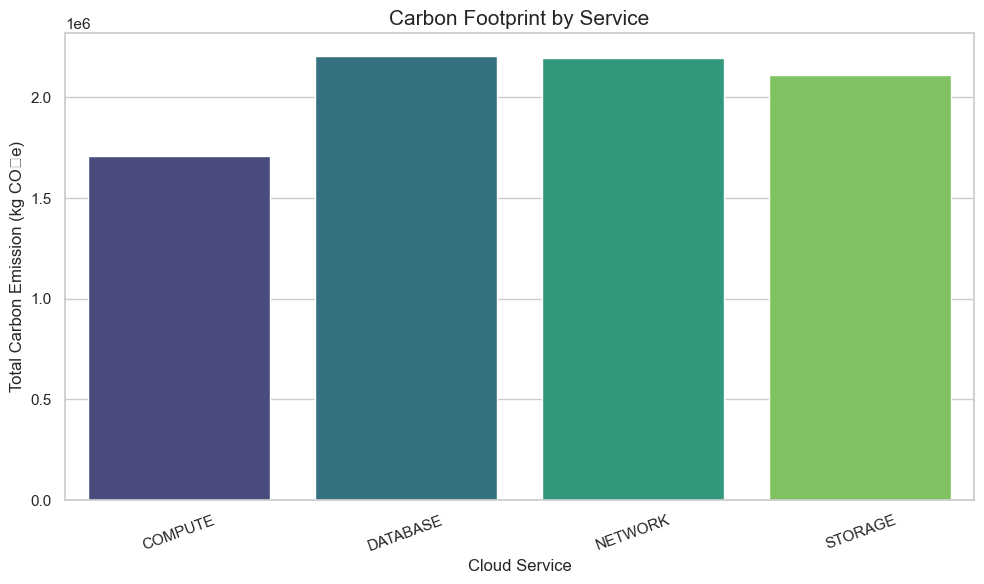

In [76]:
# Close any previous figures
plt.close('all')

# Create a new figure
fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=service_carbon,
    x="Service",
    y="Total_Carbon",
    palette="viridis",
    ax=ax
)

ax.set_title("Carbon Footprint by Service", fontsize=15)
ax.set_xlabel("Cloud Service")
ax.set_ylabel("Total Carbon Emission (kg CO₂e)")

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [77]:
# Clean Region and Service
carbon["Region_y"] = (carbon["Region_y"].astype(str).str.strip().str.upper())
carbon["Service"] = (carbon["Service"].astype(str).str.strip().str.upper())

# Remove duplicate usage records
carbon = carbon.drop_duplicates(subset=["Usage_ID"])

# Create Carbon Cube
carbon_cube = (carbon.groupby(["Region_y", "Service"], as_index=False).agg(
        Carbon_Emission=("Carbon_Emission", "sum"),
        Total_Cost=("Cost", "sum"),
        Total_Usage=("Usage", "sum")))

print(carbon_cube.head())

     Region_y   Service  Carbon_Emission  Total_Cost  Total_Usage
0  AP-SOUTH-1   COMPUTE        434350.23   123015.84      1537698
1  AP-SOUTH-1  DATABASE        639618.45   150817.76      1885222
2  AP-SOUTH-1   NETWORK        681453.60   184159.36      2301992
3  AP-SOUTH-1   STORAGE        570453.36   147899.12      1848739
4   EU-WEST-1   COMPUTE        448372.82   120919.20      1511490


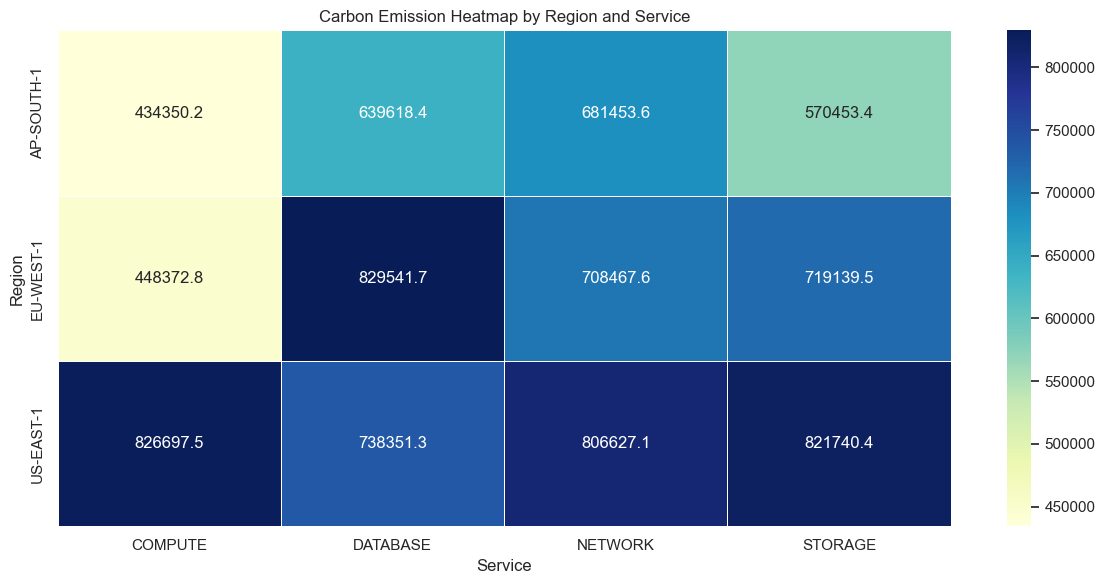

In [78]:
# Create Pivot Table
pivot = carbon_cube.pivot_table(index="Region_y",columns="Service",values="Carbon_Emission",aggfunc="sum",fill_value=0)
# Plot Heatmap
plt.figure(figsize=(12, 6))

sns.heatmap(
    pivot,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu",
    linewidths=0.5
)

plt.title("Carbon Emission Heatmap by Region and Service")
plt.xlabel("Service")
plt.ylabel("Region")

plt.tight_layout()
plt.show()

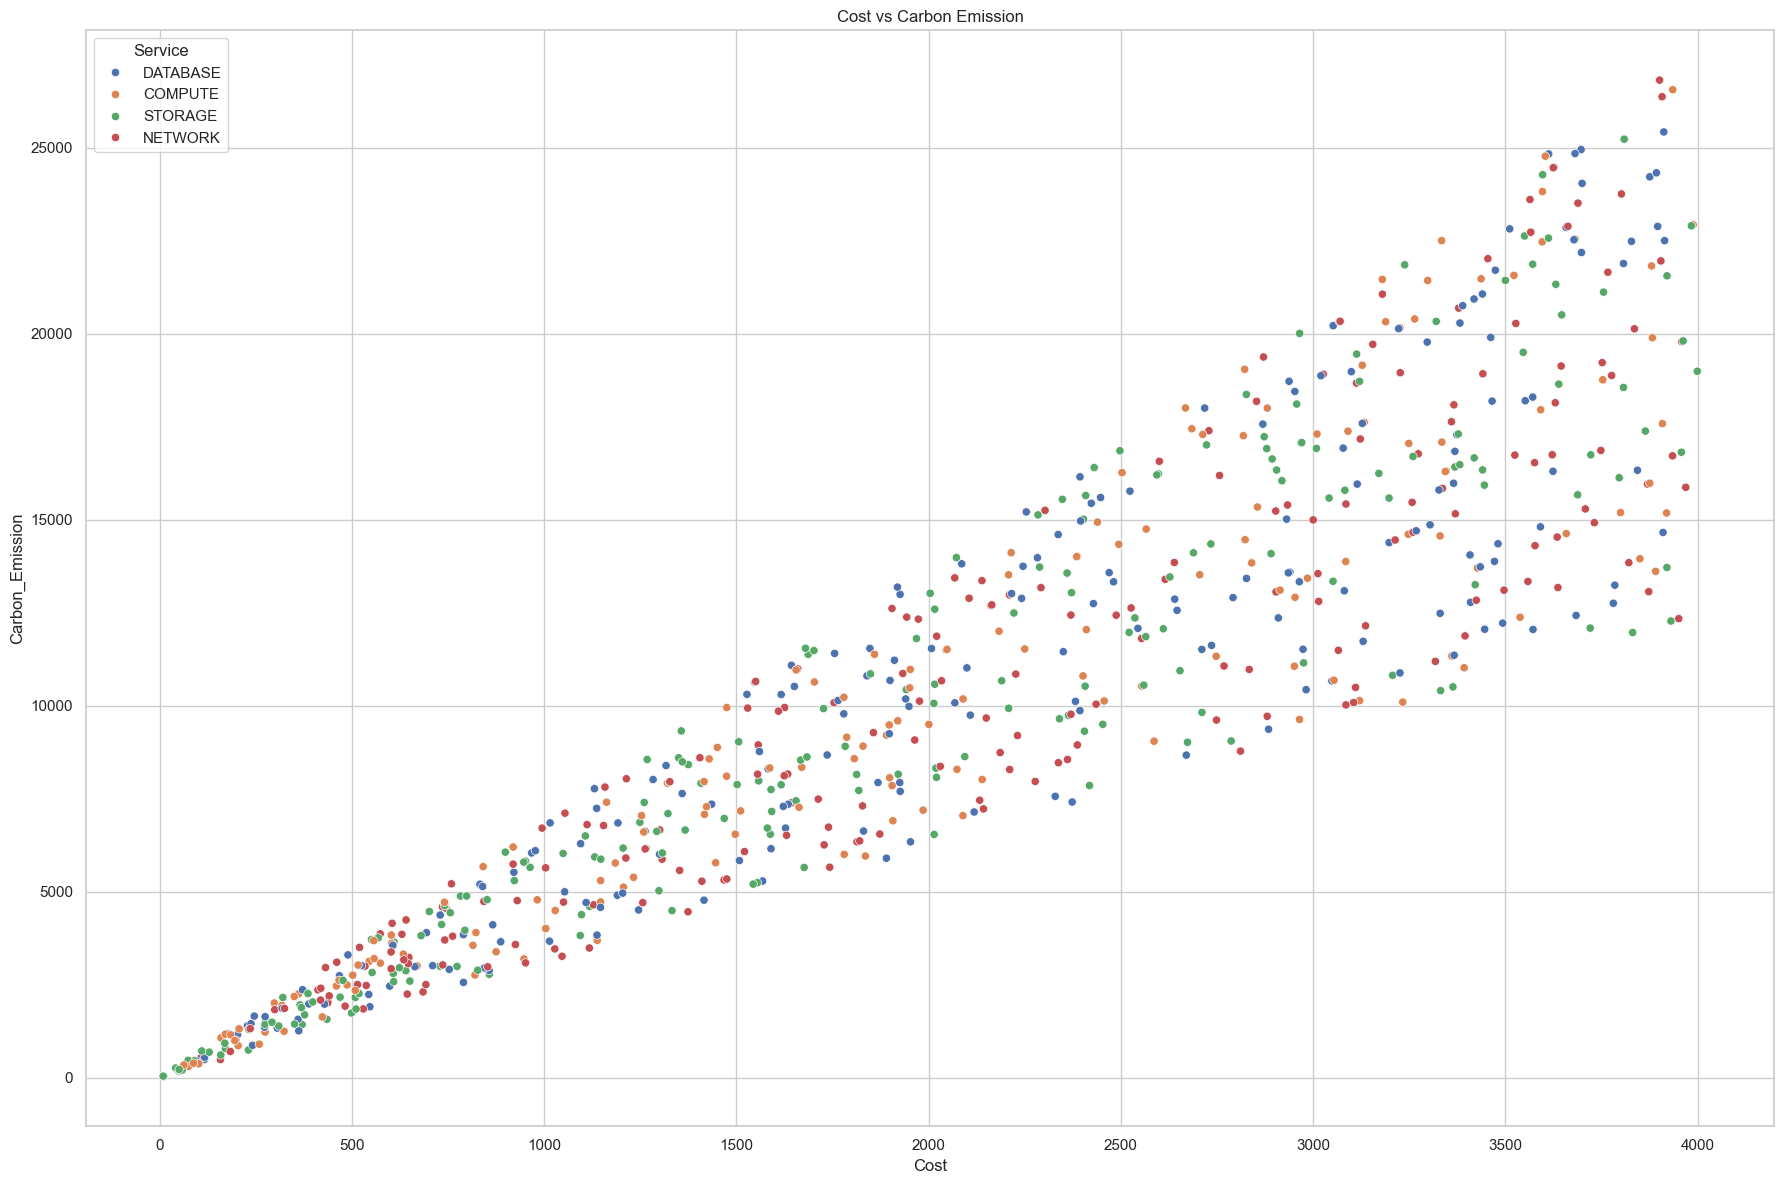

In [79]:
# Cost vs Carbon Emission
plt.figure(figsize=(18,12))

sns.scatterplot( data=carbon, x="Cost", y="Carbon_Emission", hue="Service" )

plt.title("Cost vs Carbon Emission")

plt.tight_layout()

plt.show()

In [80]:
# Region Carbon Report
region_carbon = (carbon.groupby("Region_y", as_index=False).agg(
        Total_Carbon=("Carbon_Emission", "sum"),
        Total_Usage=("Usage", "sum"),
        Total_Cost=("Cost", "sum")))

# Service Carbon Report
service_carbon = (carbon.groupby("Service", as_index=False).agg(
        Total_Carbon=("Carbon_Emission", "sum"),
        Total_Usage=("Usage", "sum"),
        Total_Cost=("Cost", "sum")))

# Carbon Cube
carbon_cube = (carbon.groupby(["Region_y", "Service"], as_index=False).agg(
        Carbon_Emission=("Carbon_Emission", "sum"),
        Total_Usage=("Usage", "sum"),
        Total_Cost=("Cost", "sum")))

In [81]:
region_carbon.to_csv(
    "Region_Carbon_Report.csv",
    index=False
)

service_carbon.to_csv(
    "Service_Carbon_Report.csv",
    index=False
)

carbon_cube.to_csv(
    "Carbon_Cube.csv",
    index=False
)

TC : 10 Cost forecast with seasonality and growth.
---------------------------------------------------

In [82]:
billing["TS"] = pd.to_datetime(billing["TS"])

# Creating the month column
billing["Month"] = billing["TS"].dt.to_period("M").astype(str)

# Monthly Cost 
monthly_cost = ( billing.groupby("Month", as_index=False).agg(
        Monthly_Cost=("Cost", "sum"),
        Monthly_Usage=("Usage", "sum")
    ) )

print(monthly_cost)

     Month  Monthly_Cost  Monthly_Usage
0  2026-01     354418.96        4430237
1  2026-02     373021.76        4662772
2  2026-03     422513.76        5281422
3  2026-04     371612.72        4645159
4  2026-05     316228.24        3952853
5  2026-06     182378.08        2279726


In [83]:
# Create Trend Feature
monthly_cost["Month_No"] = np.arange(1, len(monthly_cost) + 1)

# Calculate Monthly Growth Rate
monthly_cost["Growth_%"] = ( monthly_cost["Monthly_Cost"].pct_change() * 100 ).round(2)

# Calculate the avg growth
avg_growth = ( monthly_cost["Growth_%"].dropna().mean() )

print(f"Average Growth Rate: {avg_growth:.2f}%")

Average Growth Rate: -10.15%


In [138]:
# Forcast for next 3 months 
forecast = monthly_cost.copy()

last_cost = forecast.iloc[-1]["Monthly_Cost"]

future = []

for i in range(1, 4):

    last_cost = last_cost * (1 + avg_growth / 100)

    future.append(last_cost)

future_months = pd.date_range(
    start=pd.to_datetime(monthly_cost.iloc[-1]["Month"]) + pd.offsets.MonthBegin(),
    periods=3,
    freq="MS"
).strftime("%Y-%m")

forecast_df = pd.DataFrame({
    "Month": future_months,
    "Forecast_Cost": future
})

print(forecast_df)

     Month  Forecast_Cost
0  2026-07  163863.057318
1  2026-08  147227.679739
2  2026-09  132281.125692


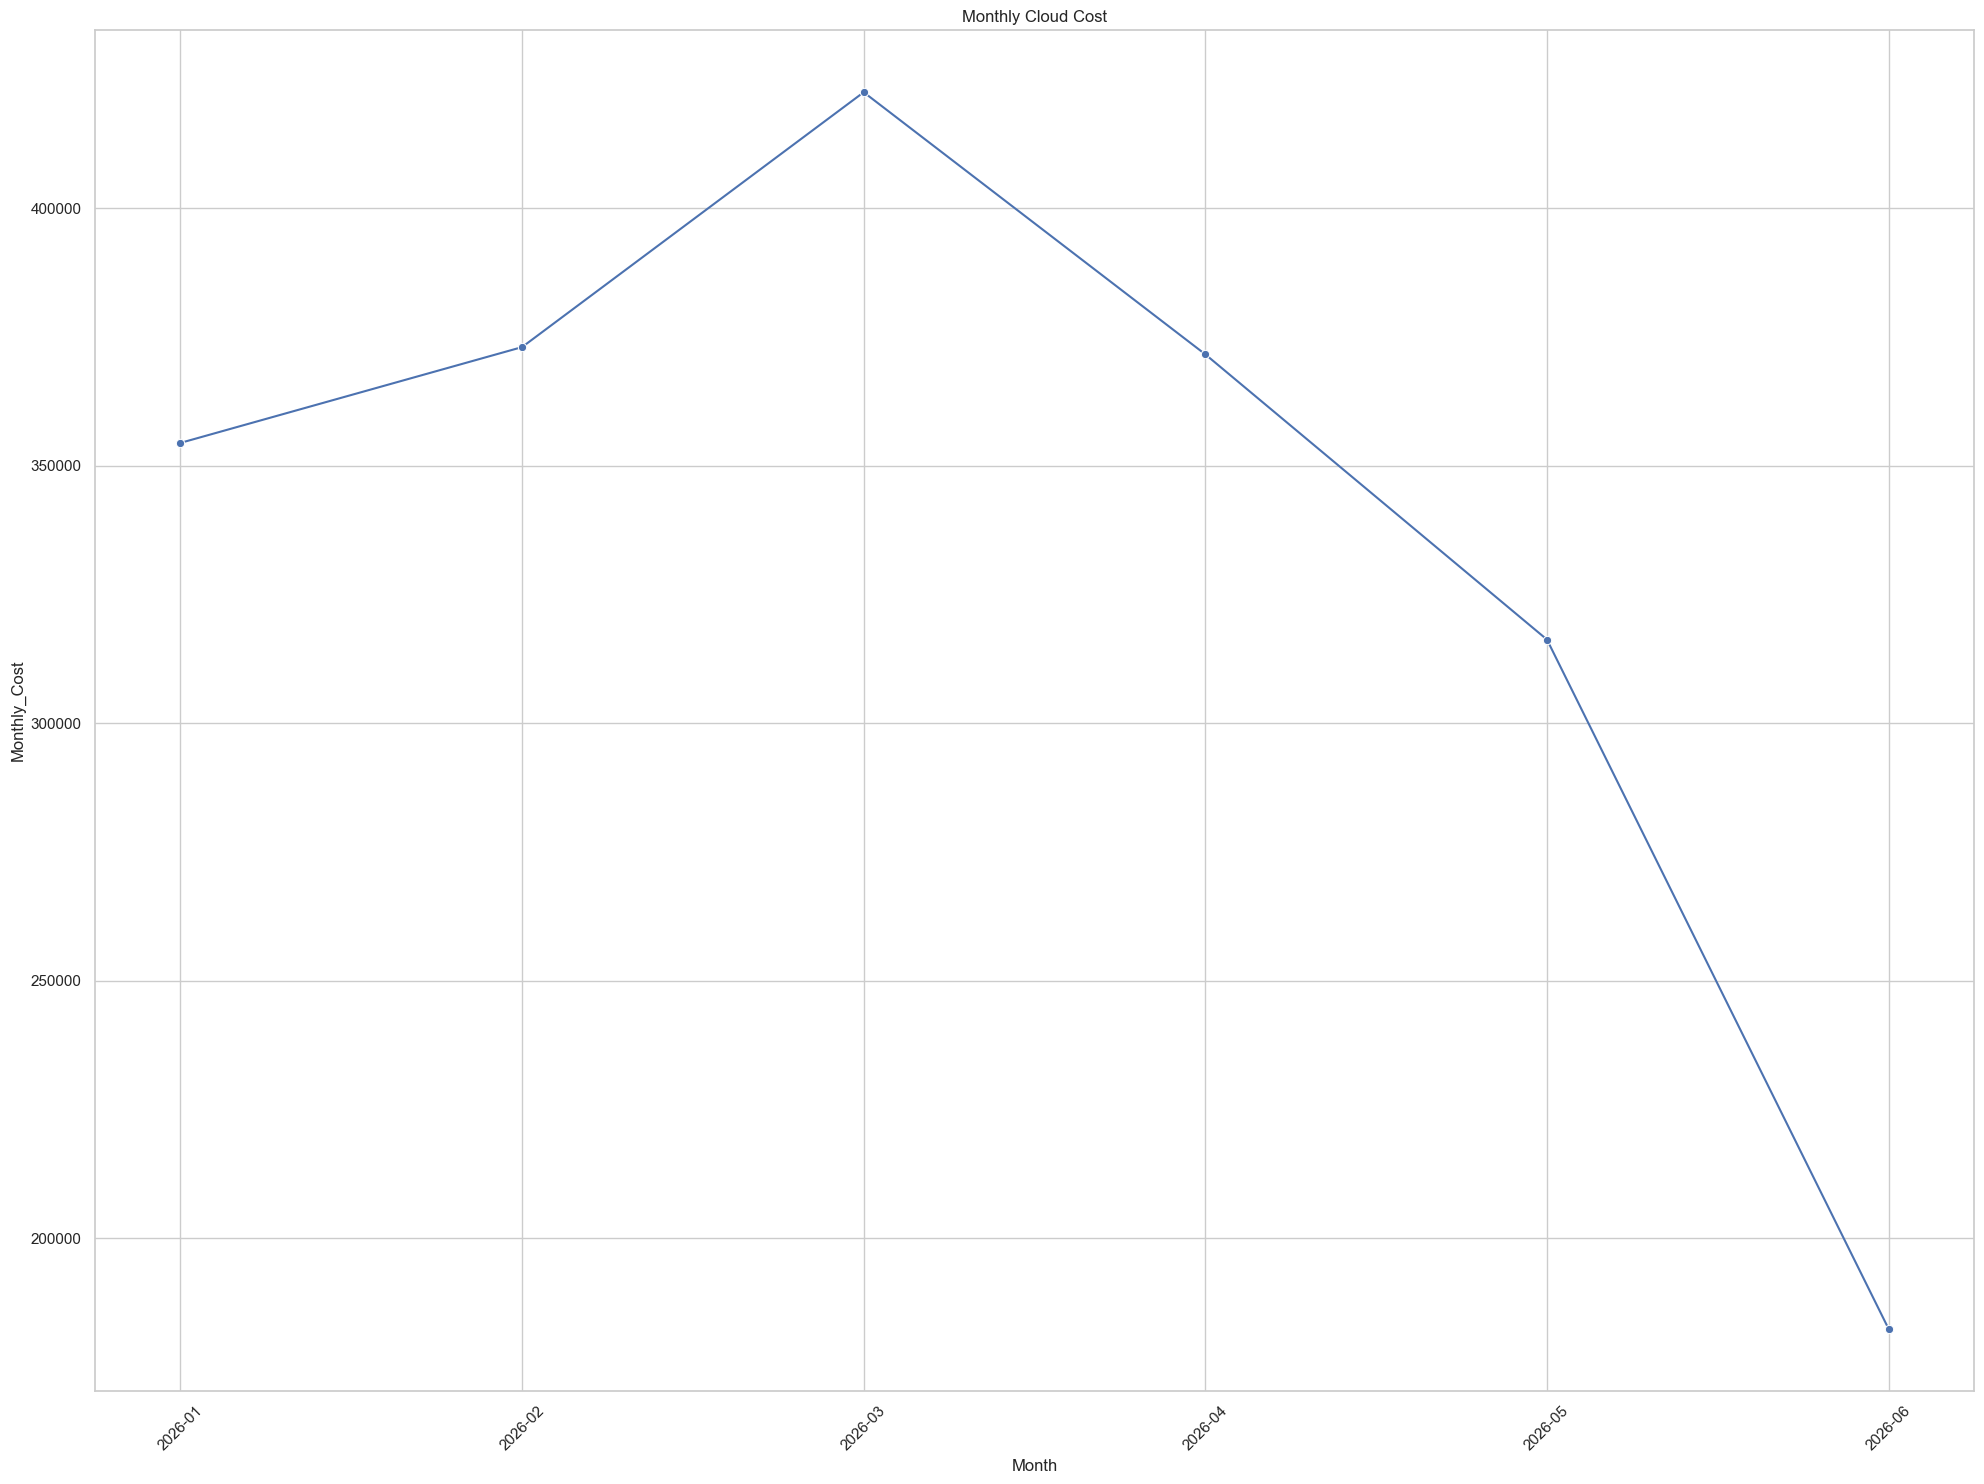

In [139]:
# Monthly Cost Trend
plt.figure(figsize=(20,15))

sns.lineplot( data=monthly_cost, x="Month", y="Monthly_Cost", marker="o" )

plt.title("Monthly Cloud Cost")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

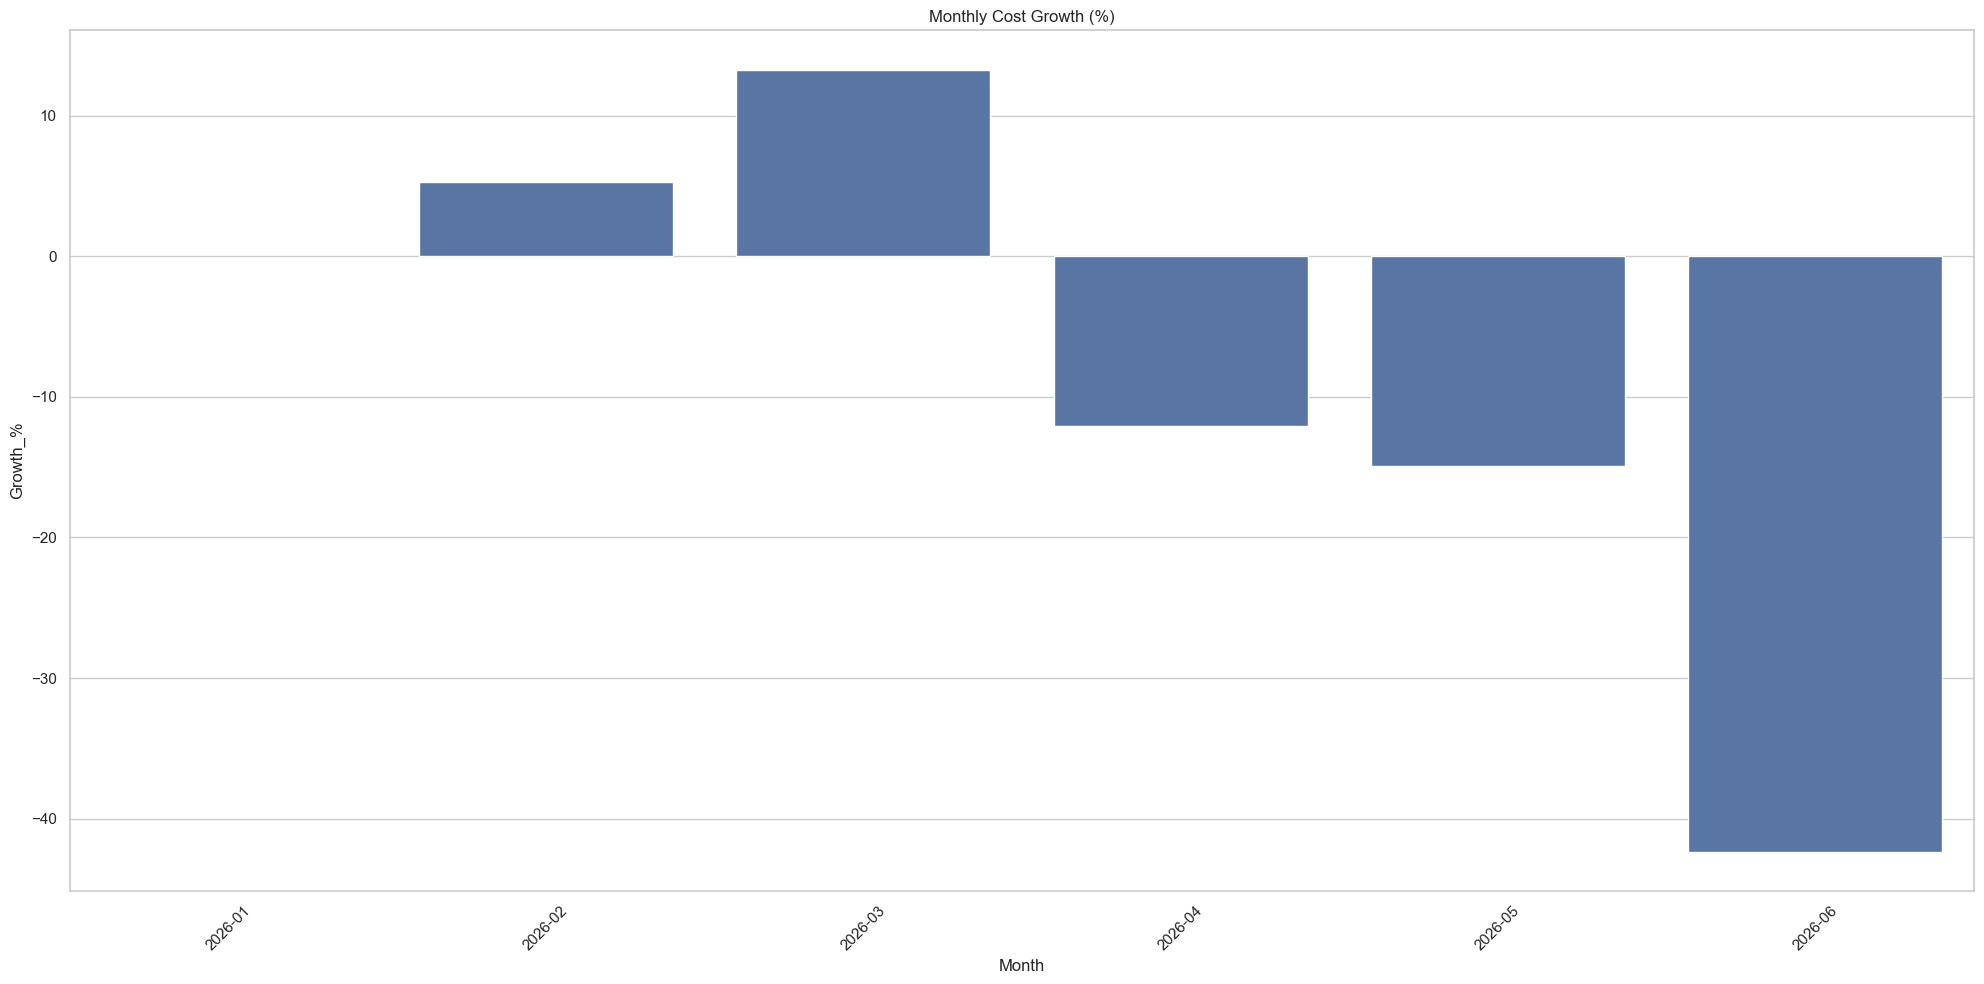

In [140]:
# Growth Percentage
plt.figure(figsize=(20,10))

sns.barplot( data=monthly_cost, x="Month", y="Growth_%" )

plt.title("Monthly Cost Growth (%)")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

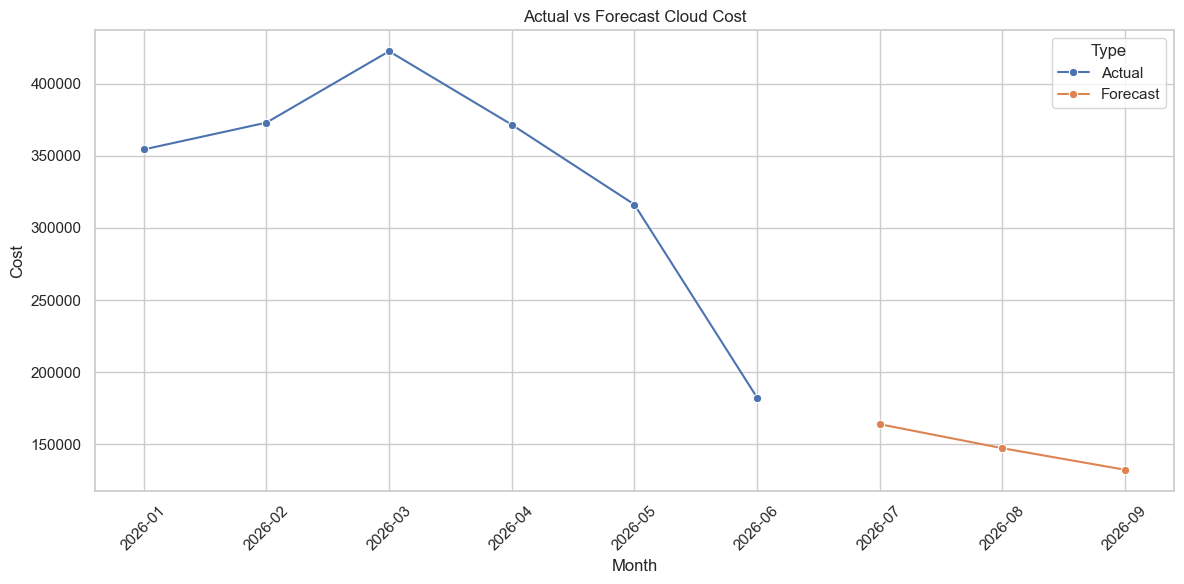

In [141]:
# Actual vs Forecast
forecast_plot = pd.concat([
    monthly_cost[["Month", "Monthly_Cost"]].rename(
        columns={"Monthly_Cost": "Cost"}
    ),
    forecast_df.rename(
        columns={"Forecast_Cost": "Cost"}
    )
])

forecast_plot["Type"] = ( ["Actual"] * len(monthly_cost) + ["Forecast"] * len(forecast_df) )

plt.figure(figsize=(12,6))

sns.lineplot( data=forecast_plot, x="Month", y="Cost", hue="Type", marker="o" )

plt.title("Actual vs Forecast Cloud Cost")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

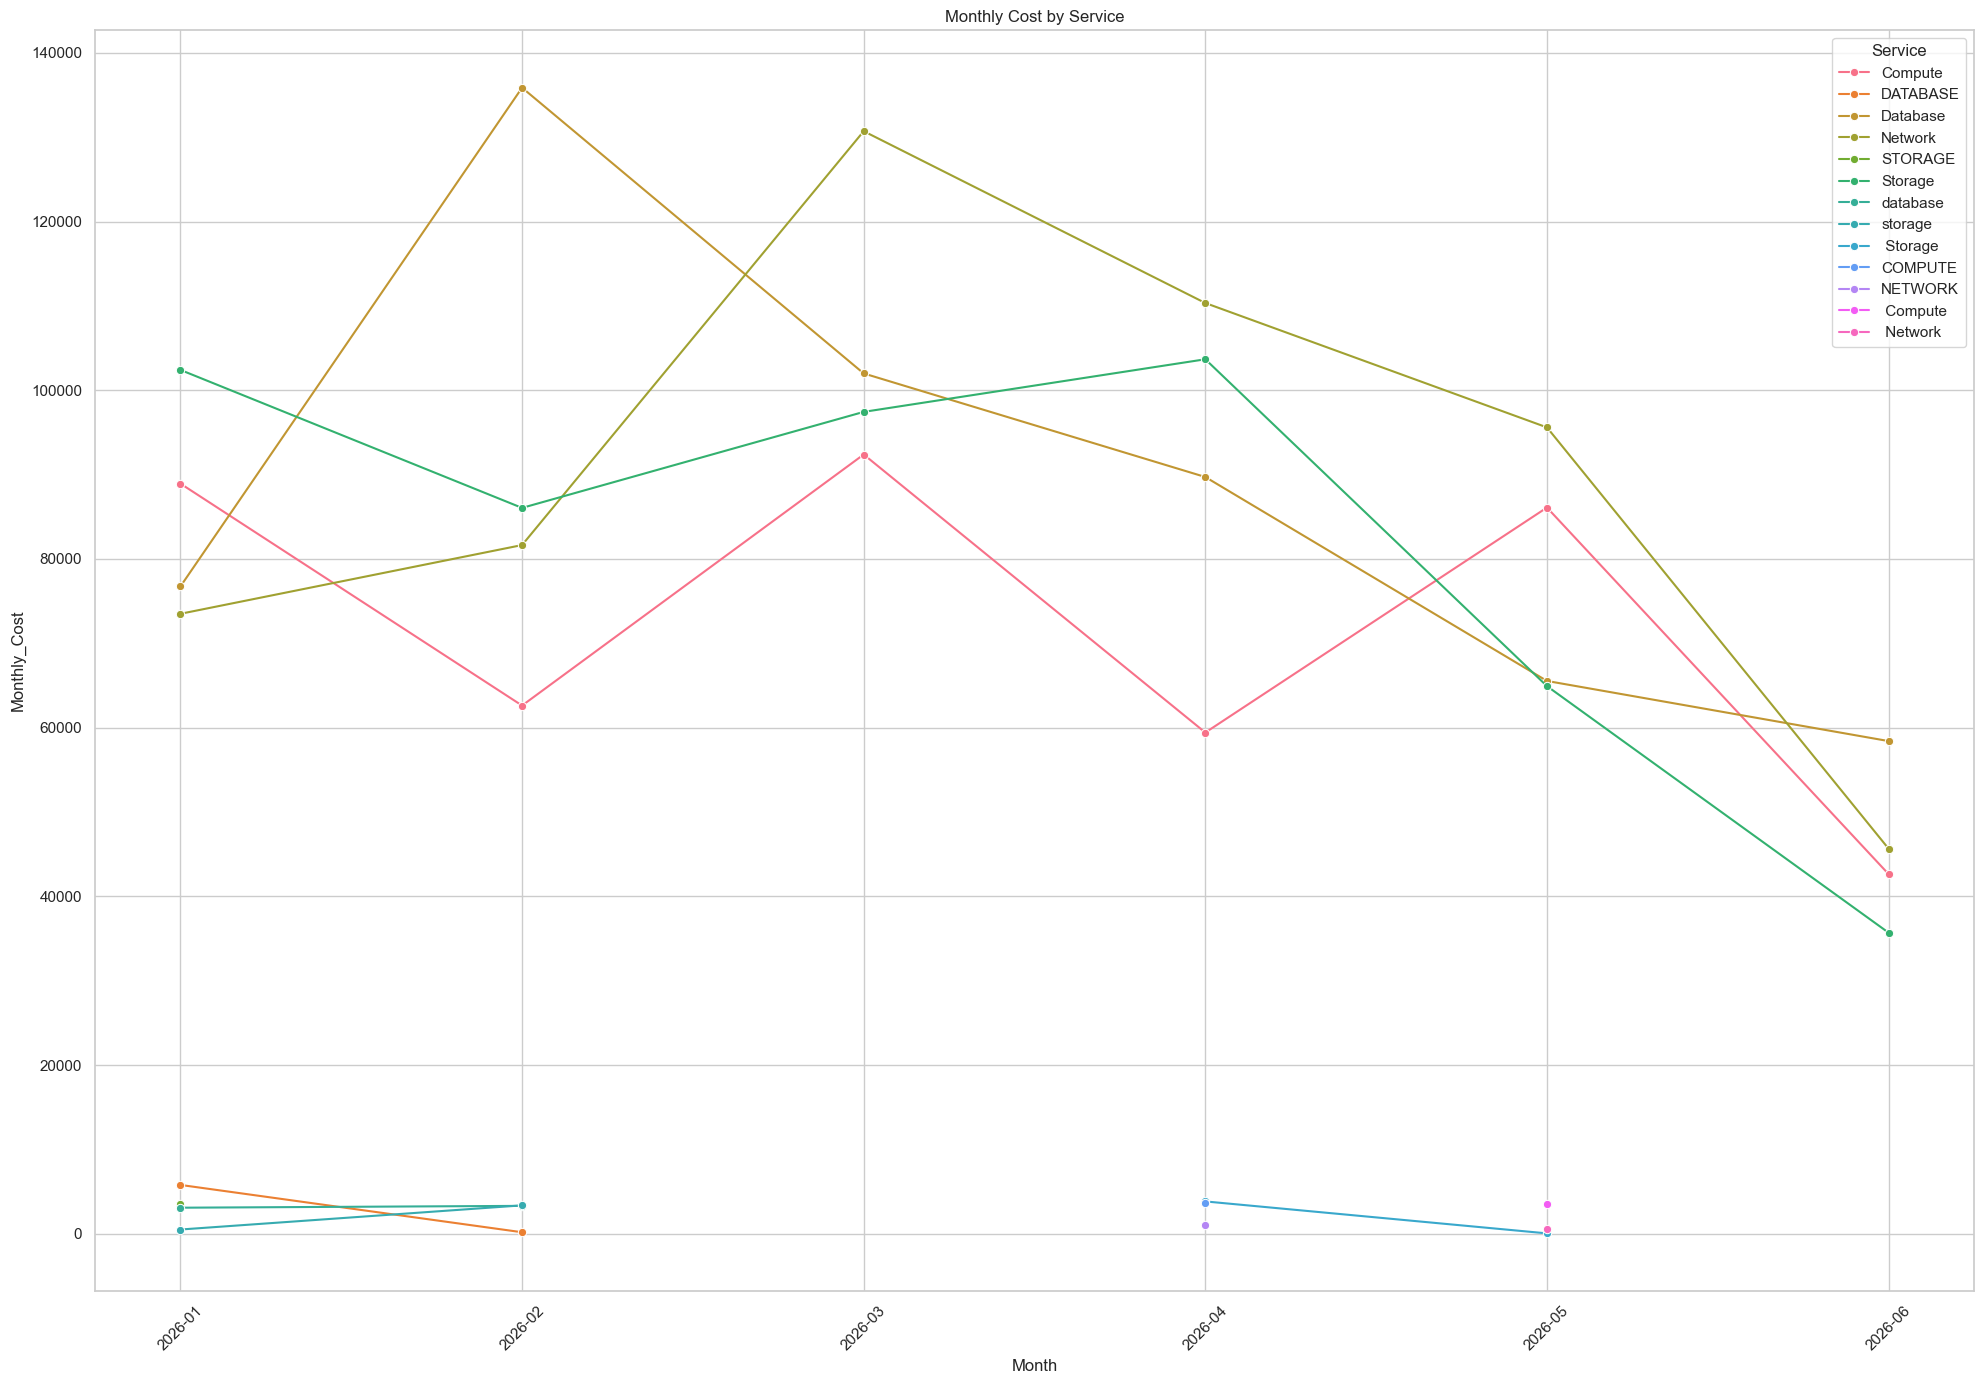

In [142]:
# Service-wise Monthly Cost
service_month = (
    billing
    .groupby(
        ["Month", "Service"],
        as_index=False
    )
    .agg(
        Monthly_Cost=("Cost", "sum")
    )
)

plt.figure(figsize=(20,14))

sns.lineplot( data=service_month, x="Month", y="Monthly_Cost", hue="Service", marker="o" )

plt.title("Monthly Cost by Service")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

TC : 11 Tag completeness scorecards.
-------------------------------------

In [87]:
# Remove duplicate resources
resource = resource.drop_duplicates(subset="Resource_ID").copy()

# Clean categorical columns
cols = [
    "Region",
    "Environment",
    "Purchase_Type",
    "Status",
    "Owner"
]

for col in cols:
    resource[col] = (
        resource[col]
        .astype(str)
        .str.strip()
        .str.upper()
        .replace("NAN", np.nan)
    )

In [88]:
# TAG COMPLETENESS
tag_columns = [
    "Owner",
    "Environment",
    "Purchase_Type",
    "Status"
]

resource["Tags_Present"] = (
    resource[tag_columns]
    .notna()
    .sum(axis=1)
)

resource["Tag_Completeness_%"] = (
    resource["Tags_Present"] / len(tag_columns)
) * 100

resource["Tag_Score"] = resource["Tag_Completeness_%"]


# ===========================================
# SCORECARD FUNCTION
# ===========================================

def scorecard(score):

    if score == 100:
        return "Excellent"

    elif score >= 80:
        return "Good"

    elif score >= 60:
        return "Average"

    else:
        return "Poor"


resource["Tag_Status"] = resource["Tag_Completeness_%"].apply(scorecard)

In [ ]:
# SCORECARD SUMMARY
scorecard_summary = (
    resource
    .groupby("Tag_Status", as_index=False)
    .agg(Resource_Count=("Resource_ID", "count"))
)

# REGION SCORE
region_score = (
    resource
    .groupby("Region", as_index=False)
    .agg(
        Average_Tag_Score=("Tag_Completeness_%", "mean")
    )
    .sort_values("Region")
)

# ENVIRONMENT SCORE
environment_score = (
    resource
    .groupby("Environment", as_index=False)
    .agg(
        Average_Tag_Score=("Tag_Completeness_%", "mean")
    )
    .sort_values("Environment")
)

print(scorecard_summary)
print(region_score)
print(environment_score)

  Tag_Status  Resource_Count
0    Average               2
1  Excellent             298
       Region  Average_Tag_Score
0  AP-SOUTH-1          99.484536
1   EU-WEST-1         100.000000
2   US-EAST-1         100.000000
  Environment  Average_Tag_Score
0         DEV          99.744898
1        PROD         100.000000
2          QA          99.750000


C:\Users\KIIT\AppData\Local\Temp\ipykernel_11344\3279399607.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


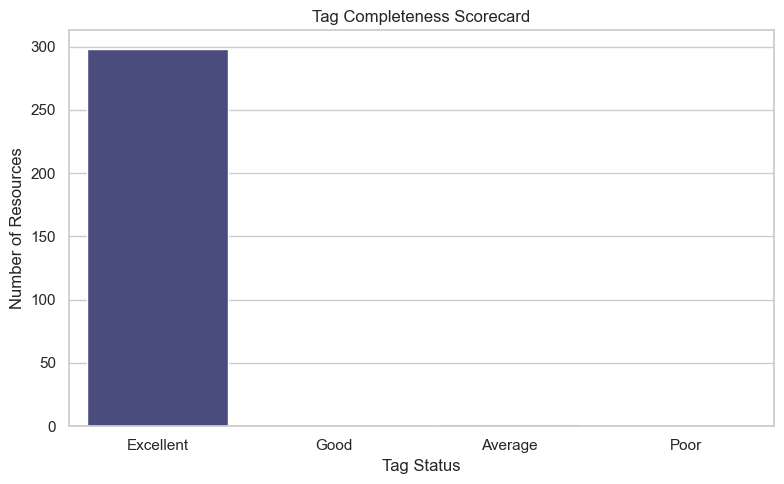

In [90]:
# PLOT 1
plt.figure(figsize=(8,5))

sns.countplot(
    data=resource,
    x="Tag_Status",
    order=["Excellent","Good","Average","Poor"],
    palette="viridis"
)

plt.title("Tag Completeness Scorecard")
plt.xlabel("Tag Status")
plt.ylabel("Number of Resources")

plt.tight_layout()
plt.show()

C:\Users\KIIT\AppData\Local\Temp\ipykernel_11344\3716499061.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


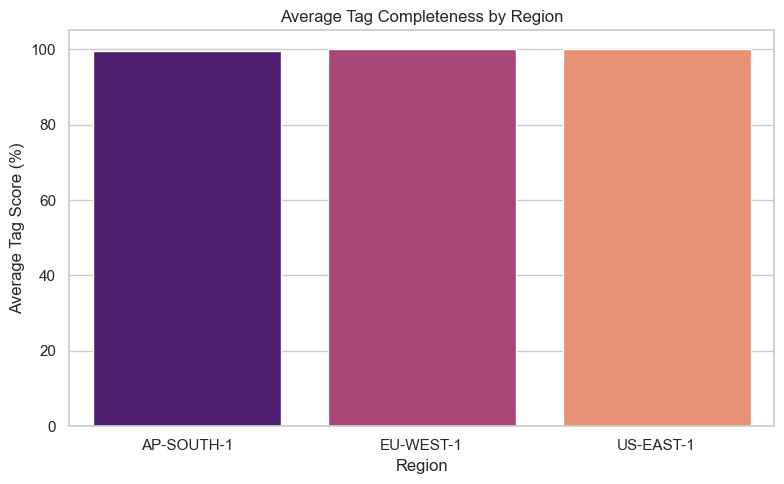

In [91]:
# PLOT 2
plt.figure(figsize=(8,5))

sns.barplot(
    data=region_score,
    x="Region",
    y="Average_Tag_Score",
    palette="magma"
)

plt.title("Average Tag Completeness by Region")
plt.ylabel("Average Tag Score (%)")

plt.tight_layout()
plt.show()


C:\Users\KIIT\AppData\Local\Temp\ipykernel_11344\3153768360.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


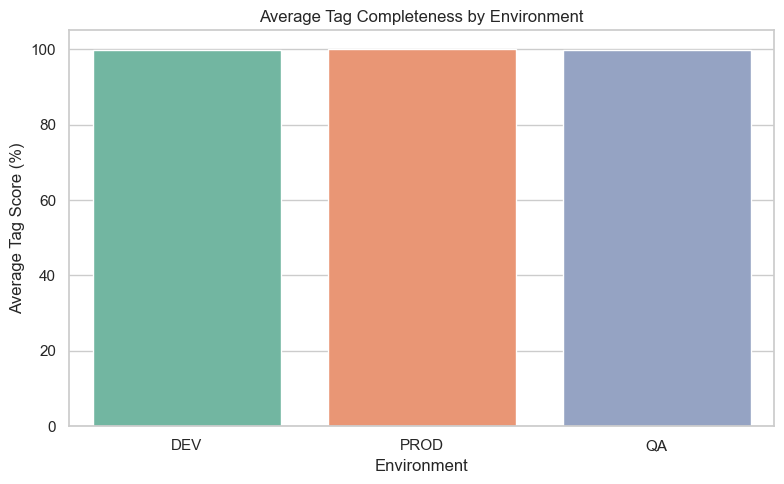

In [92]:
# PLOT 3
plt.figure(figsize=(8,5))

sns.barplot(
    data=environment_score,
    x="Environment",
    y="Average_Tag_Score",
    palette="Set2"
)

plt.title("Average Tag Completeness by Environment")
plt.ylabel("Average Tag Score (%)")

plt.tight_layout()
plt.show()


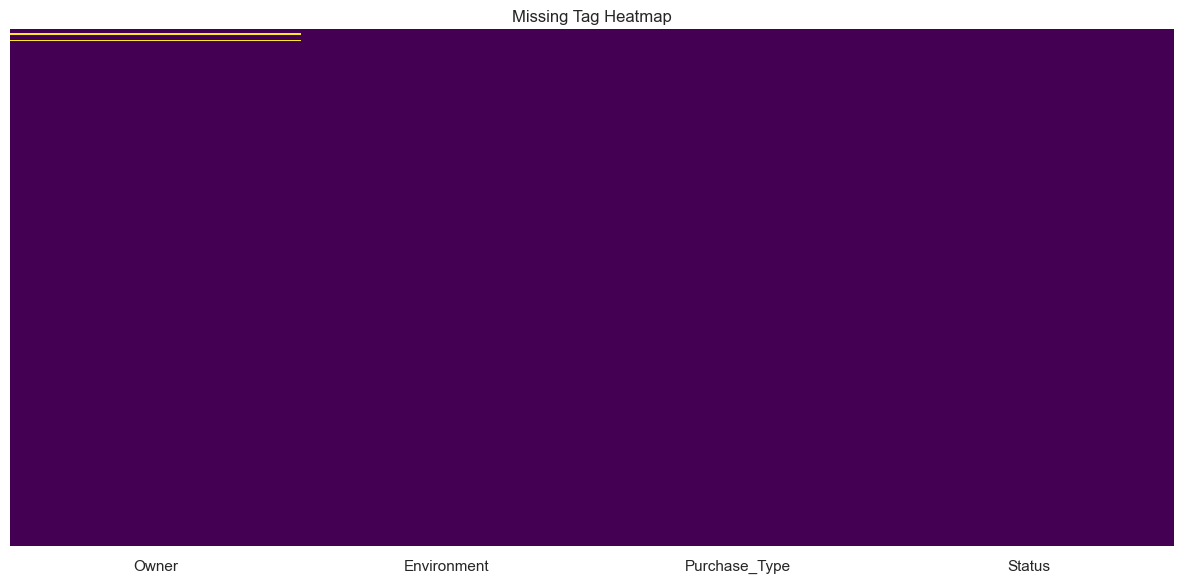

In [93]:
# PLOT 4
plt.figure(figsize=(12,6))

sns.heatmap(
    resource[tag_columns].isnull(),
    cmap="viridis",
    cbar=False,
    yticklabels=False
)

plt.title("Missing Tag Heatmap")

plt.tight_layout()
plt.show()


In [94]:
# EXPORT
resource.to_csv(
    "Tag_Completeness_Report.csv",
    index=False
)

scorecard_summary.to_csv(
    "Tag_Scorecard_Summary.csv",
    index=False
)

region_score.to_csv(
    "Region_Tag_Score.csv",
    index=False
)

environment_score.to_csv(
    "Environment_Tag_Score.csv",
    index=False
)

print("Reports Exported Successfully")

Reports Exported Successfully


TC : 12 FinOps KPIs (Blended rate, Effective discounts).
----------------------------------------------------------

In [96]:
# Remove duplicate billing records
billing = billing.drop_duplicates(subset="Usage_ID").copy()

# Clean Service names
billing["Service"] = (
    billing["Service"]
    .astype(str)
    .str.strip()
    .str.upper()
)

# Convert Date
billing["TS"] = pd.to_datetime(billing["TS"])

billing["Month"] = billing["TS"].dt.strftime("%Y-%m")

# Convert Numeric Columns
numeric_cols = [
    "Cost",
    "Credit_Amount",
    "Usage"
]

for col in numeric_cols:
    billing[col] = pd.to_numeric(
        billing[col],
        errors="coerce"
    )

# Replace missing values
billing["Credit_Amount"] = billing["Credit_Amount"].fillna(0)


In [97]:
# NET COST
billing["Net_Cost"] = (
    billing["Cost"] +
    billing["Credit_Amount"]
)

# BLENDED RATE
billing["Blended_Rate"] = np.where(
    billing["Usage"] > 0,
    billing["Net_Cost"] / billing["Usage"],
    np.nan
)

# EFFECTIVE DISCOUNT
billing["Effective_Discount_%"] = np.where(
    billing["Cost"] > 0,
    (billing["Credit_Amount"] / billing["Cost"]) * 100,
    0
)

billing["Effective_Discount_%"] = (
    billing["Effective_Discount_%"]
    .round(2)
)


In [98]:
# MONTHLY KPI
monthly_kpi = (
    billing
    .groupby("Month", as_index=False)
    .agg(
        Total_Cost=("Cost","sum"),
        Net_Cost=("Net_Cost","sum"),
        Total_Credits=("Credit_Amount","sum"),
        Total_Usage=("Usage","sum")
    )
)

monthly_kpi["Blended_Rate"] = np.where(
    monthly_kpi["Total_Usage"] > 0,
    monthly_kpi["Net_Cost"] /
    monthly_kpi["Total_Usage"],
    np.nan
)

# SERVICE KPI
service_kpi = (
    billing
    .groupby("Service", as_index=False)
    .agg(
        Total_Cost=("Cost","sum"),
        Net_Cost=("Net_Cost","sum"),
        Credits=("Credit_Amount","sum"),
        Usage=("Usage","sum")
    )
)

service_kpi["Blended_Rate"] = np.where(
    service_kpi["Usage"] > 0,
    service_kpi["Net_Cost"] /
    service_kpi["Usage"],
    np.nan
)

# CREDIT SUMMARY
credit_service = (
    billing
    .groupby("Service", as_index=False)
    .agg(
        Credit_Amount=("Credit_Amount","sum")
    )
)


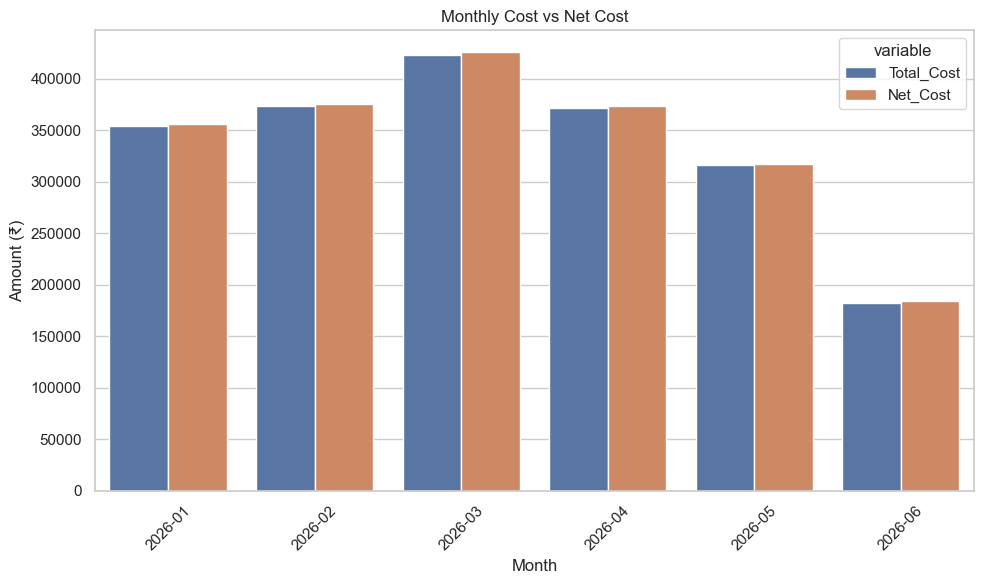

In [99]:
# GRAPH 1
monthly_plot = monthly_kpi.melt(
    id_vars="Month",
    value_vars=["Total_Cost","Net_Cost"]
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=monthly_plot,
    x="Month",
    y="value",
    hue="variable"
)

plt.title("Monthly Cost vs Net Cost")
plt.xlabel("Month")
plt.ylabel("Amount (₹)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


C:\Users\KIIT\AppData\Local\Temp\ipykernel_11344\4214616780.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


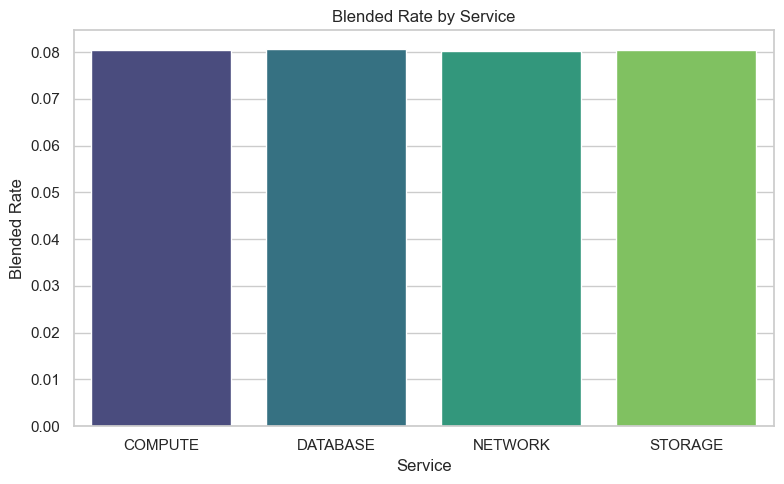

In [100]:
# GRAPH 2
plt.figure(figsize=(8,5))

sns.barplot(
    data=service_kpi,
    x="Service",
    y="Blended_Rate",
    palette="viridis"
)

plt.title("Blended Rate by Service")
plt.xlabel("Service")
plt.ylabel("Blended Rate")

plt.tight_layout()
plt.show()


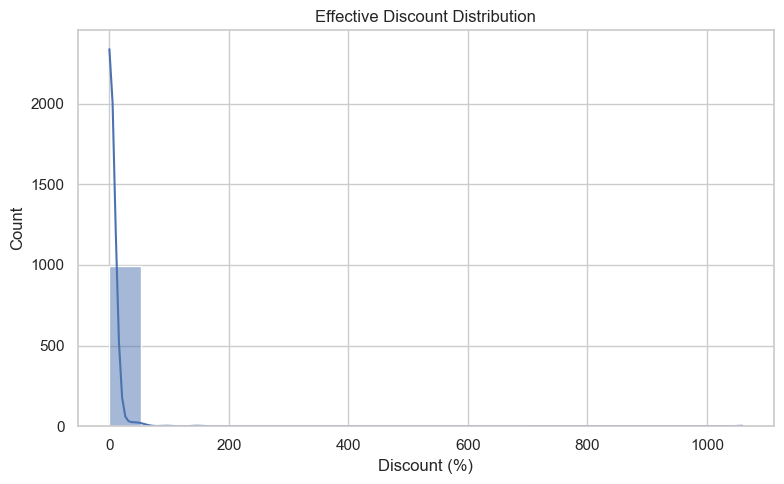

In [101]:
# GRAPH 3
plt.figure(figsize=(8,5))

sns.histplot(
    billing["Effective_Discount_%"],
    bins=20,
    kde=True
)

plt.title("Effective Discount Distribution")
plt.xlabel("Discount (%)")

plt.tight_layout()
plt.show()



C:\Users\KIIT\AppData\Local\Temp\ipykernel_11344\2827222491.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


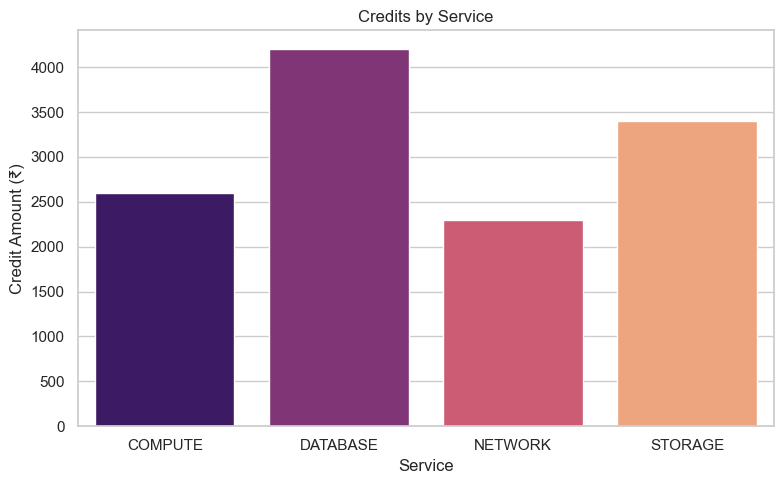

In [102]:
# GRAPH 4
plt.figure(figsize=(8,5))

sns.barplot(
    data=credit_service,
    x="Service",
    y="Credit_Amount",
    palette="magma"
)

plt.title("Credits by Service")
plt.xlabel("Service")
plt.ylabel("Credit Amount (₹)")

plt.tight_layout()
plt.show()

TC : 13 Optimization opportunity backlog (snooze/commit).
-----------------------------------------------------------

In [103]:
# Remove duplicate billing records
billing = billing.drop_duplicates(subset="Usage_ID").copy()

# Remove duplicate resource records
resource = resource.drop_duplicates(subset="Resource_ID").copy()

# Clean merge keys
billing["Resource_ID"] = billing["Resource_ID"].astype(str).str.strip().str.upper()
resource["Resource_ID"] = resource["Resource_ID"].astype(str).str.strip().str.upper()

billing["Account"] = billing["Account"].astype(str).str.strip().str.upper()
resource["Account"] = resource["Account"].astype(str).str.strip().str.upper()

# Clean Service
billing["Service"] = (
    billing["Service"]
    .astype(str)
    .str.strip()
    .str.upper()
)

# Clean Region
resource["Region"] = (
    resource["Region"]
    .astype(str)
    .str.strip()
    .str.upper()
)


In [104]:
# MERGE
optimization = billing.merge(
    resource,
    on=["Resource_ID", "Account"],
    how="left",
    validate="many_to_one"
)


In [105]:
# RECOMMENDATION
conditions = [

    (
        (optimization["CPU_Utilization"] < 20) &
        (optimization["Memory_Utilization"] < 20)
    ),

    (
        (optimization["CPU_Utilization"] >= 20) &
        (optimization["CPU_Utilization"] < 40)
    )

]

choices = [
    "Commit",
    "Snooze"
]

optimization["Recommendation"] = np.select(
    conditions,
    choices,
    default="Healthy"
)

# PRIORITY

priority_map = {
    "Commit":"High",
    "Snooze":"Medium",
    "Healthy":"Low"
}

optimization["Priority"] = (
    optimization["Recommendation"]
    .map(priority_map)
)

# ESTIMATED SAVINGS
optimization["Estimated_Savings"] = np.select(

    [
        optimization["Recommendation"]=="Commit",
        optimization["Recommendation"]=="Snooze"
    ],

    [
        optimization["Cost"]*0.30,
        optimization["Cost"]*0.10
    ],

    default=0

)


In [107]:
# SUMMARY
summary = (

    optimization

    .groupby("Recommendation",as_index=False)

    .agg(

        Resources=("Resource_ID","nunique"),

        Total_Cost=("Cost","sum"),

        Potential_Savings=("Estimated_Savings","sum")

    )

)

print(summary)

# SERVICE SUMMARY
service_summary = (

    optimization

    .groupby(
        ["Service","Recommendation"],
        as_index=False
    )

    .agg(

        Resources=("Resource_ID","nunique"),

        Savings=("Estimated_Savings","sum")

    )

)


  Recommendation  Resources  Total_Cost  Potential_Savings
0        Healthy        287  2016387.52              0.000
1         Snooze          2     3240.64            324.064


In [108]:
# Detect the correct region column
if "Region" in optimization.columns:
    region_col = "Region"
elif "Region_y" in optimization.columns:
    region_col = "Region_y"
elif "Region_x" in optimization.columns:
    region_col = "Region_x"
else:
    raise ValueError("No Region column found in optimization DataFrame.")

region_summary = (
    optimization
    .groupby(region_col, as_index=False)
    .agg(
        Savings=("Estimated_Savings", "sum")
    )
    .sort_values("Savings", ascending=False)
)

print(region_summary)

     Region_y  Savings
1   EU-WEST-1  324.064
0  AP-SOUTH-1    0.000


C:\Users\KIIT\AppData\Local\Temp\ipykernel_11344\663756640.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


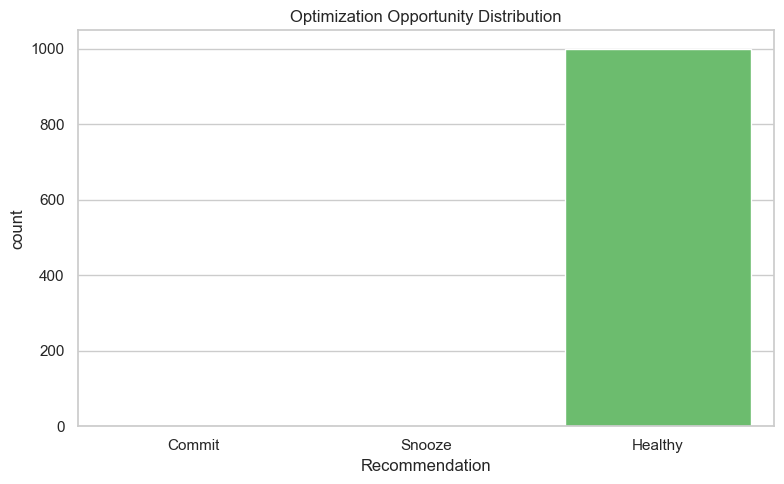

In [109]:
# GRAPH 1
plt.figure(figsize=(8,5))

sns.countplot(
    data=optimization,
    x="Recommendation",
    order=["Commit","Snooze","Healthy"],
    palette="viridis"
)

plt.title("Optimization Opportunity Distribution")

plt.tight_layout()

plt.show()

C:\Users\KIIT\AppData\Local\Temp\ipykernel_11344\1335858663.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


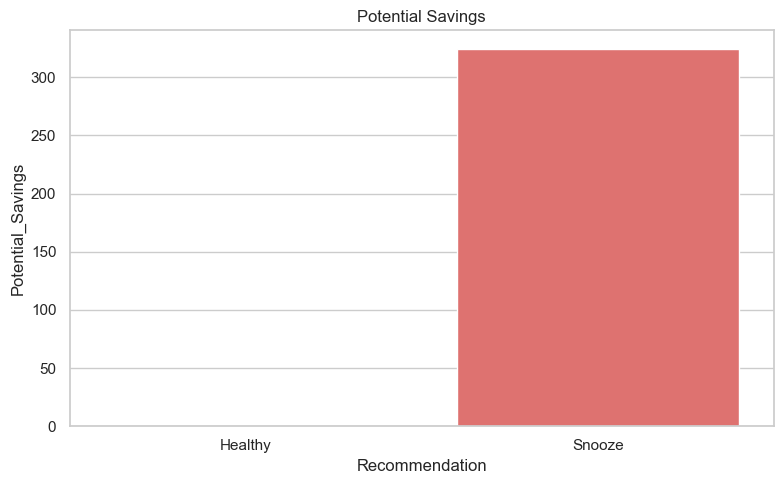

In [110]:
# GRAPH 2
plt.figure(figsize=(8,5))

sns.barplot(
    data=summary,
    x="Recommendation",
    y="Potential_Savings",
    palette="magma"
)

plt.title("Potential Savings")

plt.tight_layout()

plt.show()

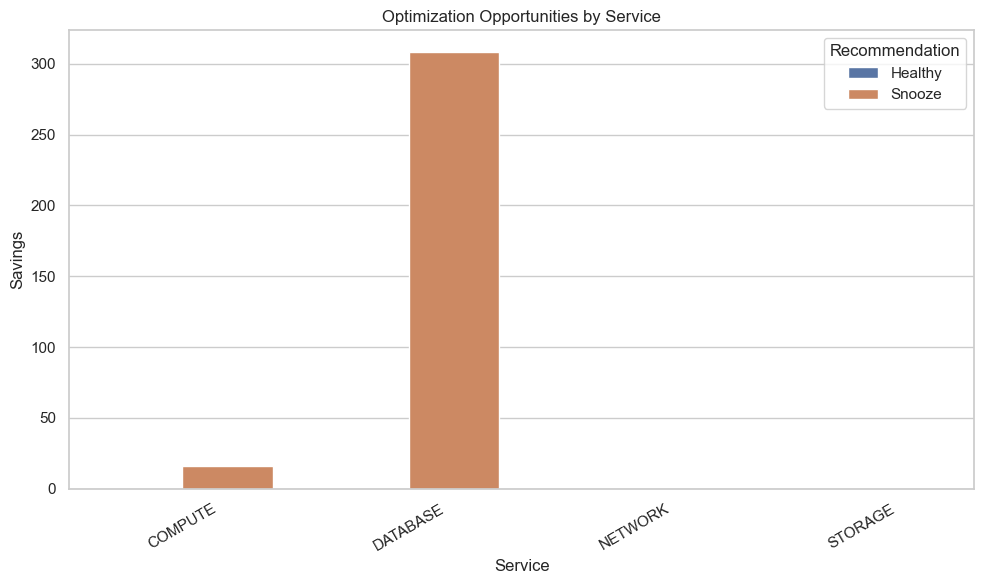

In [111]:
# GRAPH 3
plt.figure(figsize=(10,6))

sns.barplot(
    data=service_summary,
    x="Service",
    y="Savings",
    hue="Recommendation"
)

plt.title("Optimization Opportunities by Service")

plt.xticks(rotation=30)

plt.tight_layout()

plt.show()

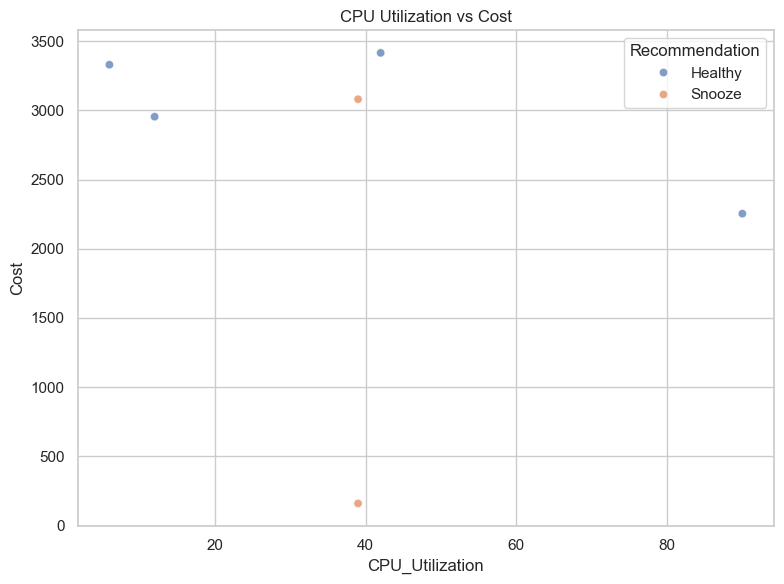

In [112]:
# GRAPH 4
cpu_plot = optimization.drop_duplicates(
    subset=["Usage_ID"]
)

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=cpu_plot,
    x="CPU_Utilization",
    y="Cost",
    hue="Recommendation",
    alpha=0.7
)

plt.title("CPU Utilization vs Cost")

plt.tight_layout()

plt.show()



In [114]:
region_summary = region_summary.rename(
    columns={
        "Region_y": "Region",
        "Region_x": "Region"
    }
)

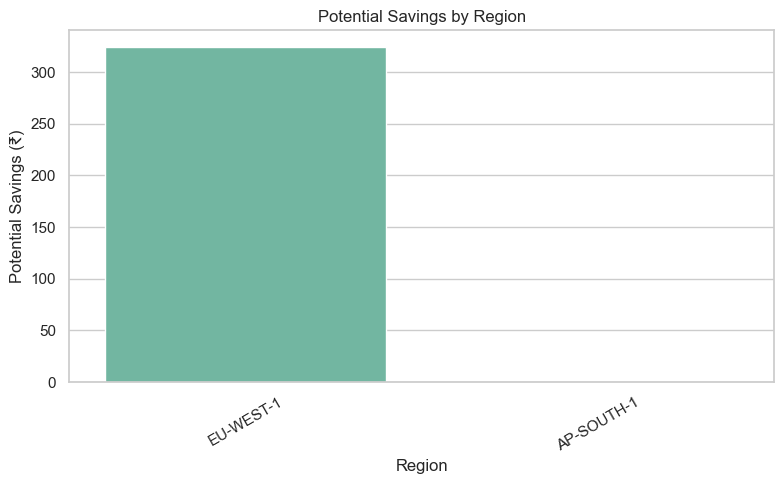

In [115]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=region_summary,
    x="Region",
    y="Savings",
    hue="Region",
    palette="Set2",
    legend=False
)

plt.title("Potential Savings by Region")
plt.xlabel("Region")
plt.ylabel("Potential Savings (₹)")

plt.xticks(rotation=30)

plt.tight_layout()

plt.show()

In [116]:
# EXPORT
optimization.to_csv(
    "Optimization_Backlog.csv",
    index=False
)

summary.to_csv(
    "Optimization_Summary.csv",
    index=False
)

service_summary.to_csv(
    "Service_Optimization.csv",
    index=False
)

region_summary.to_csv(
    "Region_Optimization.csv",
    index=False
)

print("Optimization reports exported successfully.")

Optimization reports exported successfully.


TS : 14. Benchmarks vs industry peers (if dataset available).
=============================================================

In [117]:
# Remove duplicate billing records
billing = billing.drop_duplicates(subset="Usage_ID").copy()

# Clean Cost column
billing["Cost"] = (
    billing["Cost"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.replace("₹", "", regex=False)
    .str.replace("$", "", regex=False)
    .str.strip()
)

billing["Cost"] = pd.to_numeric(
    billing["Cost"],
    errors="coerce"
)

# Clean Service Names
billing["Service"] = (
    billing["Service"]
    .astype(str)
    .str.strip()
    .str.upper()
)


In [118]:
# COMPANY AVERAGE COST
company = (
    billing
    .groupby("Service", as_index=False)
    .agg(
        Company_Avg_Cost=("Cost", "mean")
    )
)

print(company)


    Service  Company_Avg_Cost
0   COMPUTE       1958.155000
1  DATABASE       2103.505681
2   NETWORK       2113.795137
3   STORAGE       1899.176970


In [ ]:
# INDUSTRY BENCHMARK
industry = pd.DataFrame({

    "Service":[
        "COMPUTE",
        "STORAGE",
        "DATABASE",
        "NETWORK"
    ],

    "Industry_Avg_Cost":[
        1200,
        900,
        1500,
        700
    ]

})

# MERGE
benchmark = (
    company
    .merge(
        industry,
        on="Service",
        how="inner"
    )
)

benchmark["Difference"] = (
    benchmark["Company_Avg_Cost"]
    - benchmark["Industry_Avg_Cost"]
)

benchmark["Performance"] = np.where(
    benchmark["Difference"] > 0,
    "Above Benchmark",
    "Below Benchmark"
)

print(benchmark)

    Service  Company_Avg_Cost  Industry_Avg_Cost   Difference      Performance
0   COMPUTE       1958.155000               1200   758.155000  Above Benchmark
1  DATABASE       2103.505681               1500   603.505681  Above Benchmark
2   NETWORK       2113.795137                700  1413.795137  Above Benchmark
3   STORAGE       1899.176970                900   999.176970  Above Benchmark


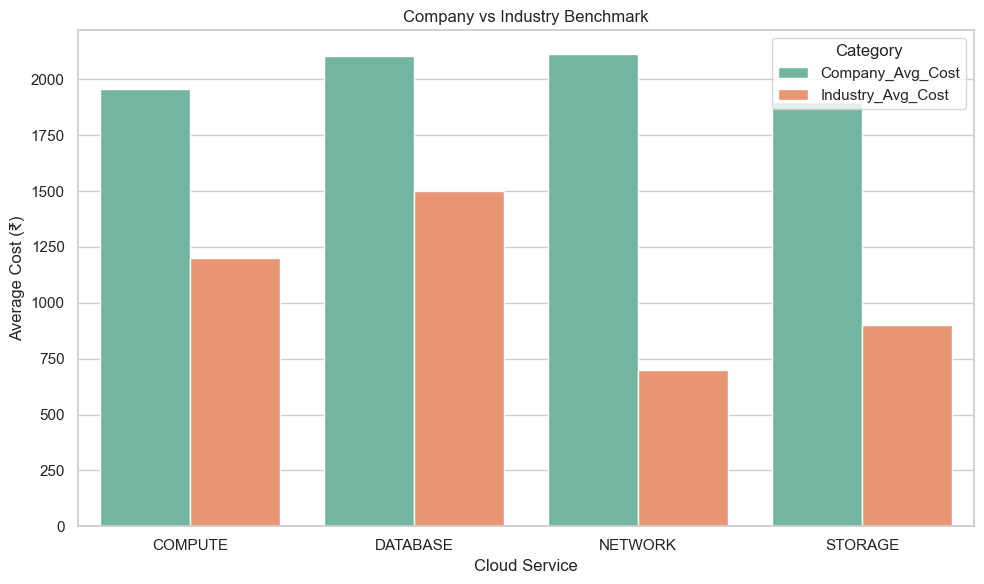

In [120]:
# VISUALIZATION
benchmark_plot = benchmark.melt(
    id_vars="Service",
    value_vars=[
        "Company_Avg_Cost",
        "Industry_Avg_Cost"
    ],
    var_name="Category",
    value_name="Average_Cost"
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=benchmark_plot,
    x="Service",
    y="Average_Cost",
    hue="Category",
    palette="Set2"
)

plt.title("Company vs Industry Benchmark")
plt.xlabel("Cloud Service")
plt.ylabel("Average Cost (₹)")

plt.tight_layout()
plt.show()

TC : 15. Support ticket topic clustering and deflection rate.
=================================================================

In [121]:
# Remove duplicate tickets
tickets = tickets.drop_duplicates(subset="Ticket_ID").copy()

# Clean Category names
tickets["Category"] = (
    tickets["Category"]
    .astype(str)
    .str.strip()
    .str.upper()
)

# TOPIC SUMMARY
topic_summary = (
    tickets
    .groupby("Category", as_index=False)
    .agg(
        Total_Tickets=("Ticket_ID", "count")
    )
    .sort_values("Total_Tickets", ascending=False)
)

print(topic_summary)


      Category  Total_Tickets
3      STORAGE             80
1        LOGIN             76
2  PERFORMANCE             74
0      BILLING             70


In [122]:
# SELF-SERVICE VS AGENT
np.random.seed(42)

tickets["Status"] = np.random.choice(
    ["Self-Service", "Agent"],
    size=len(tickets),
    p=[0.30, 0.70]
)

# DEFLECTION RATE
total_tickets = len(tickets)

deflected = (
    tickets["Status"]
    .eq("Self-Service")
    .sum()
)

deflection_rate = (
    deflected / total_tickets
) * 100

print(f"Deflection Rate: {deflection_rate:.2f}%")

Deflection Rate: 31.67%


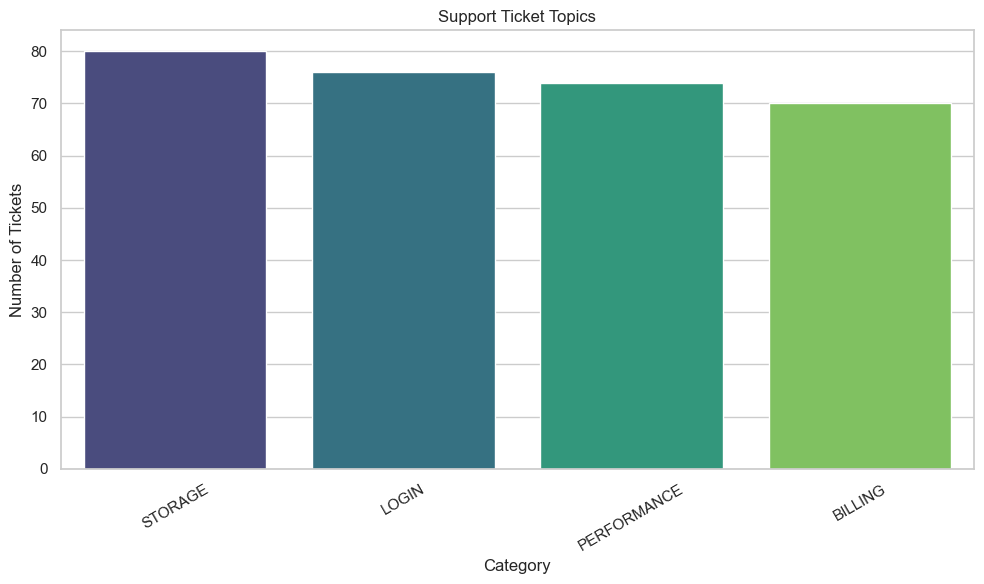

In [123]:
# PLOT
plt.figure(figsize=(10,6))

sns.barplot(
    data=topic_summary,
    x="Category",
    y="Total_Tickets",
    hue="Category",
    palette="viridis",
    legend=False
)

plt.title("Support Ticket Topics")
plt.xlabel("Category")
plt.ylabel("Number of Tickets")

plt.xticks(rotation=30)

plt.tight_layout()

plt.show()

TC : 16. Churn risk signals for SaaS (usage decay).
=========================================================

In [183]:
# Convert Timestamp
billing["TS"] = pd.to_datetime(billing["TS"])

In [184]:
# Calculate Average Usage per Customer
usage_summary = (
    billing.groupby("Account", as_index=False)
           .agg(
               Average_Usage=("Usage", "mean"),
               Total_Cost=("Cost", "sum")
           )
)

print(usage_summary.head())

      Account  Average_Usage  Total_Cost
0   ACCT1011          6719.0      537.52
1   ACCT1029          6817.0     1090.72
2   ACCT1034         30208.0     2416.64
3   ACCT1058           525.0       42.00
4   ACCT1082         47884.0     3830.72


In [185]:
# Create Churn Risk Label
def churn_risk(usage):

    if usage < 100:
        return "High Risk"

    elif usage < 300:
        return "Medium Risk"

    else:
        return "Low Risk"
# Apply the Rule
usage_summary["Churn_Risk"] = (
    usage_summary["Average_Usage"]
    .apply(churn_risk)
)

print(usage_summary.head())

      Account  Average_Usage  Total_Cost Churn_Risk
0   ACCT1011          6719.0      537.52   Low Risk
1   ACCT1029          6817.0     1090.72   Low Risk
2   ACCT1034         30208.0     2416.64   Low Risk
3   ACCT1058           525.0       42.00   Low Risk
4   ACCT1082         47884.0     3830.72   Low Risk


In [186]:
# Count Customers in Each Risk Group
risk_summary = (
    usage_summary["Churn_Risk"]
    .value_counts()
)

print(risk_summary)

Churn_Risk
Low Risk    110
Name: count, dtype: int64


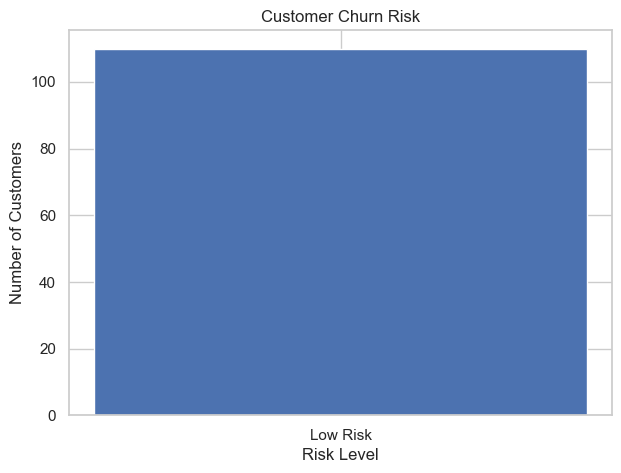

In [187]:
# Visualization
plt.figure(figsize=(7,5))

plt.bar(
    risk_summary.index,
    risk_summary.values
)

plt.title("Customer Churn Risk")

plt.xlabel("Risk Level")

plt.ylabel("Number of Customers")

plt.show()

TF : 17. Unit economics per product (gross margin proxy).
===============================================================

In [124]:
# Remove duplicate billing records
billing = billing.drop_duplicates(subset="Usage_ID").copy()

# Clean Cost column
billing["Cost"] = (
    billing["Cost"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.replace("₹", "", regex=False)
    .str.replace("$", "", regex=False)
    .str.strip()
)

billing["Cost"] = pd.to_numeric(
    billing["Cost"],
    errors="coerce"
)

# Clean Usage
billing["Usage"] = pd.to_numeric(
    billing["Usage"],
    errors="coerce"
)

# Clean Service names
billing["Service"] = (
    billing["Service"]
    .astype(str)
    .str.strip()
    .str.upper()
)


In [125]:
# SERVICE SUMMARY
service_summary = (
    billing
    .groupby("Service", as_index=False)
    .agg(
        Revenue=("Cost", "sum"),
        Total_Usage=("Usage", "sum")
    )
    .sort_values("Revenue", ascending=False)
)

# GROSS MARGIN
service_summary["Operating_Cost"] = (
    service_summary["Revenue"] * 0.70
)

service_summary["Gross_Margin"] = (
    service_summary["Revenue"] -
    service_summary["Operating_Cost"]
)

service_summary["Gross_Margin_%"] = np.where(
    service_summary["Revenue"] > 0,
    (
        service_summary["Gross_Margin"] /
        service_summary["Revenue"]
    ) * 100,
    0
)

service_summary["Gross_Margin_%"] = (
    service_summary["Gross_Margin_%"]
    .round(2)
)

print(service_summary)

    Service    Revenue  Total_Usage  Operating_Cost  Gross_Margin  \
1  DATABASE  540600.96      6757512      378420.672    162180.288   
2   NETWORK  539017.76      6737722      377312.432    161705.328   
3   STORAGE  501382.72      6267284      350967.904    150414.816   
0   COMPUTE  438626.72      5482834      307038.704    131588.016   

   Gross_Margin_%  
1            30.0  
2            30.0  
3            30.0  
0            30.0  


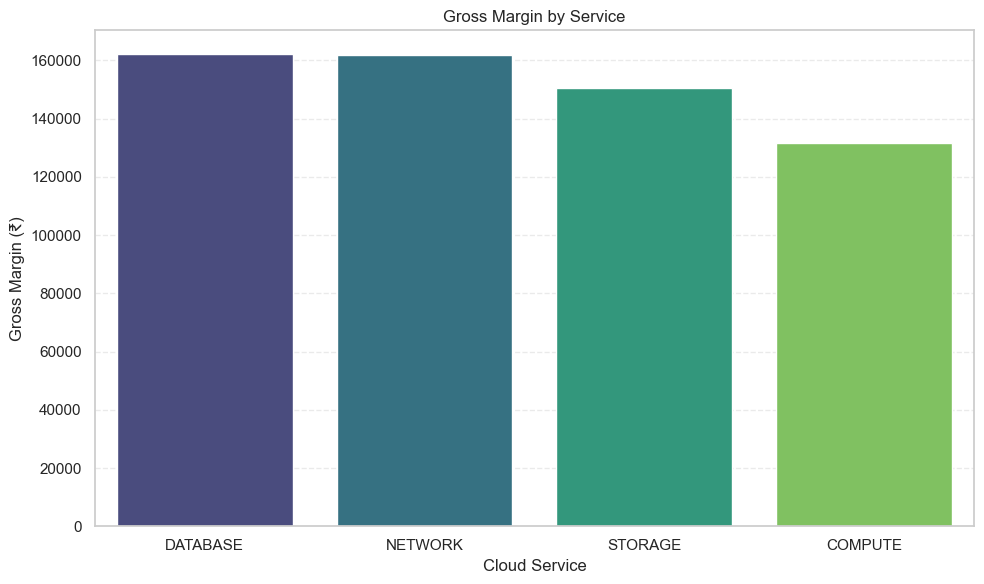

In [126]:
# GRAPH
plt.figure(figsize=(10,6))

sns.barplot(
    data=service_summary,
    x="Service",
    y="Gross_Margin",
    hue="Service",
    palette="viridis",
    legend=False
)

plt.title("Gross Margin by Service")
plt.xlabel("Cloud Service")
plt.ylabel("Gross Margin (₹)")

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

TF : 18. Multi‑cloud consolidation view.
========================================

In [193]:
providers = ["AWS", "Azure", "GCP"]

billing["Cloud_Provider"] = np.random.choice(
    providers,
    size=len(billing)
)

print(billing[["Account","Cloud_Provider"]].head())

      Account Cloud_Provider
0    ACCT1082            AWS
1   ACCT1029           Azure
2    acct1055          Azure
3    ACCT1065            GCP
4   ACCT1058             AWS


In [194]:
cloud_summary = (
    billing.groupby("Cloud_Provider", as_index=False)
           .agg(
               Total_Cost=("Cost","sum"),
               Total_Usage=("Usage","sum"),
               Total_Accounts=("Account","nunique")
           )
)

print(cloud_summary)

  Cloud_Provider  Total_Cost  Total_Usage  Total_Accounts
0            AWS   687471.92      8593399             100
1          Azure   641141.44      8014268             100
2            GCP   691560.16      8644502             102


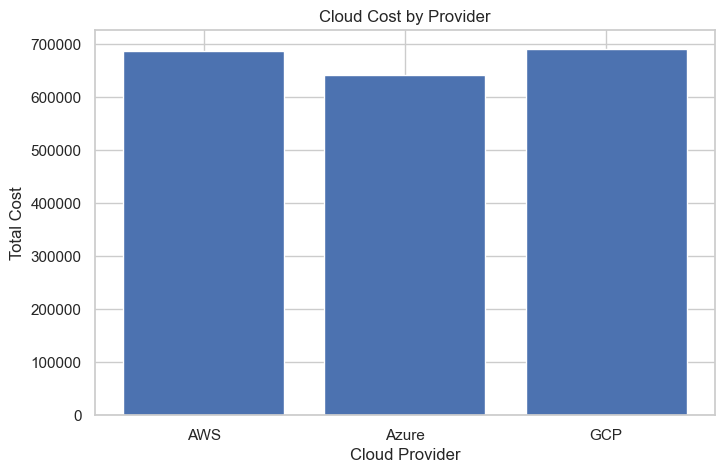

In [195]:
plt.figure(figsize=(8,5))

plt.bar(
    cloud_summary["Cloud_Provider"],
    cloud_summary["Total_Cost"]
)

plt.title("Cloud Cost by Provider")

plt.xlabel("Cloud Provider")

plt.ylabel("Total Cost")

plt.show()

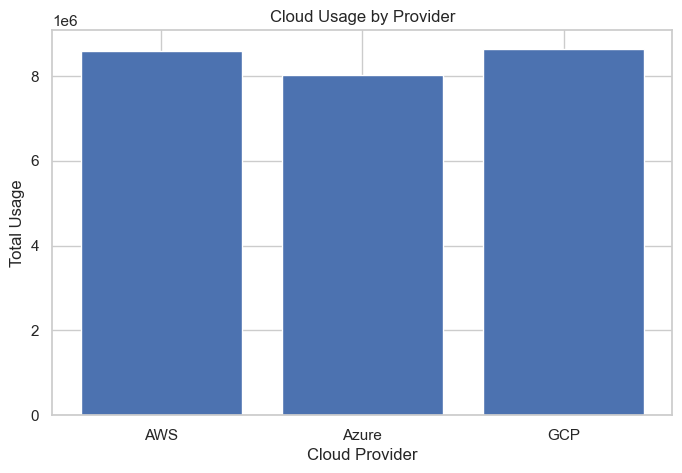

In [196]:
plt.figure(figsize=(8,5))

plt.bar(
    cloud_summary["Cloud_Provider"],
    cloud_summary["Total_Usage"]
)

plt.title("Cloud Usage by Provider")

plt.xlabel("Cloud Provider")

plt.ylabel("Total Usage")

plt.show()

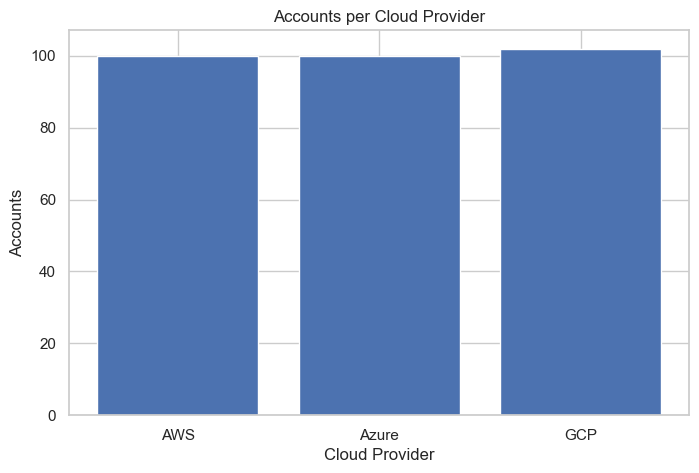

In [197]:
plt.figure(figsize=(8,5))

plt.bar(
    cloud_summary["Cloud_Provider"],
    cloud_summary["Total_Accounts"]
)

plt.title("Accounts per Cloud Provider")

plt.xlabel("Cloud Provider")

plt.ylabel("Accounts")

plt.show()

TF : 19. Security event correlation counts (from SIEM) joined to costs.
=============================================================================

In [198]:
security_count = (
    security.groupby("Resource_ID")
            .size()
            .reset_index(name="Security_Events")
)

print(security_count.head())

  Resource_ID  Security_Events
0    VM100001                1
1    VM100002                2
2    VM100003                1
3    VM100004                2
4    VM100005                5


In [199]:
cost_summary = (
    billing.groupby("Resource_ID", as_index=False)
           .agg(
               Total_Cost=("Cost", "sum")
           )
)

print(cost_summary.head())

  Resource_ID  Total_Cost
0    VM100001    13560.96
1    VM100003     8236.72
2    VM100004    11652.00
3    VM100005     5363.44
4    VM100006     2367.68


In [200]:
# Merge Billing and Security Logs
security_cost = pd.merge(
    cost_summary,
    security_count,
    on="Resource_ID",
    how="left"
)

security_cost["Security_Events"] = security_cost["Security_Events"].fillna(0)

print(security_cost.head())

  Resource_ID  Total_Cost  Security_Events
0    VM100001    13560.96              1.0
1    VM100003     8236.72              1.0
2    VM100004    11652.00              2.0
3    VM100005     5363.44              5.0
4    VM100006     2367.68              2.0


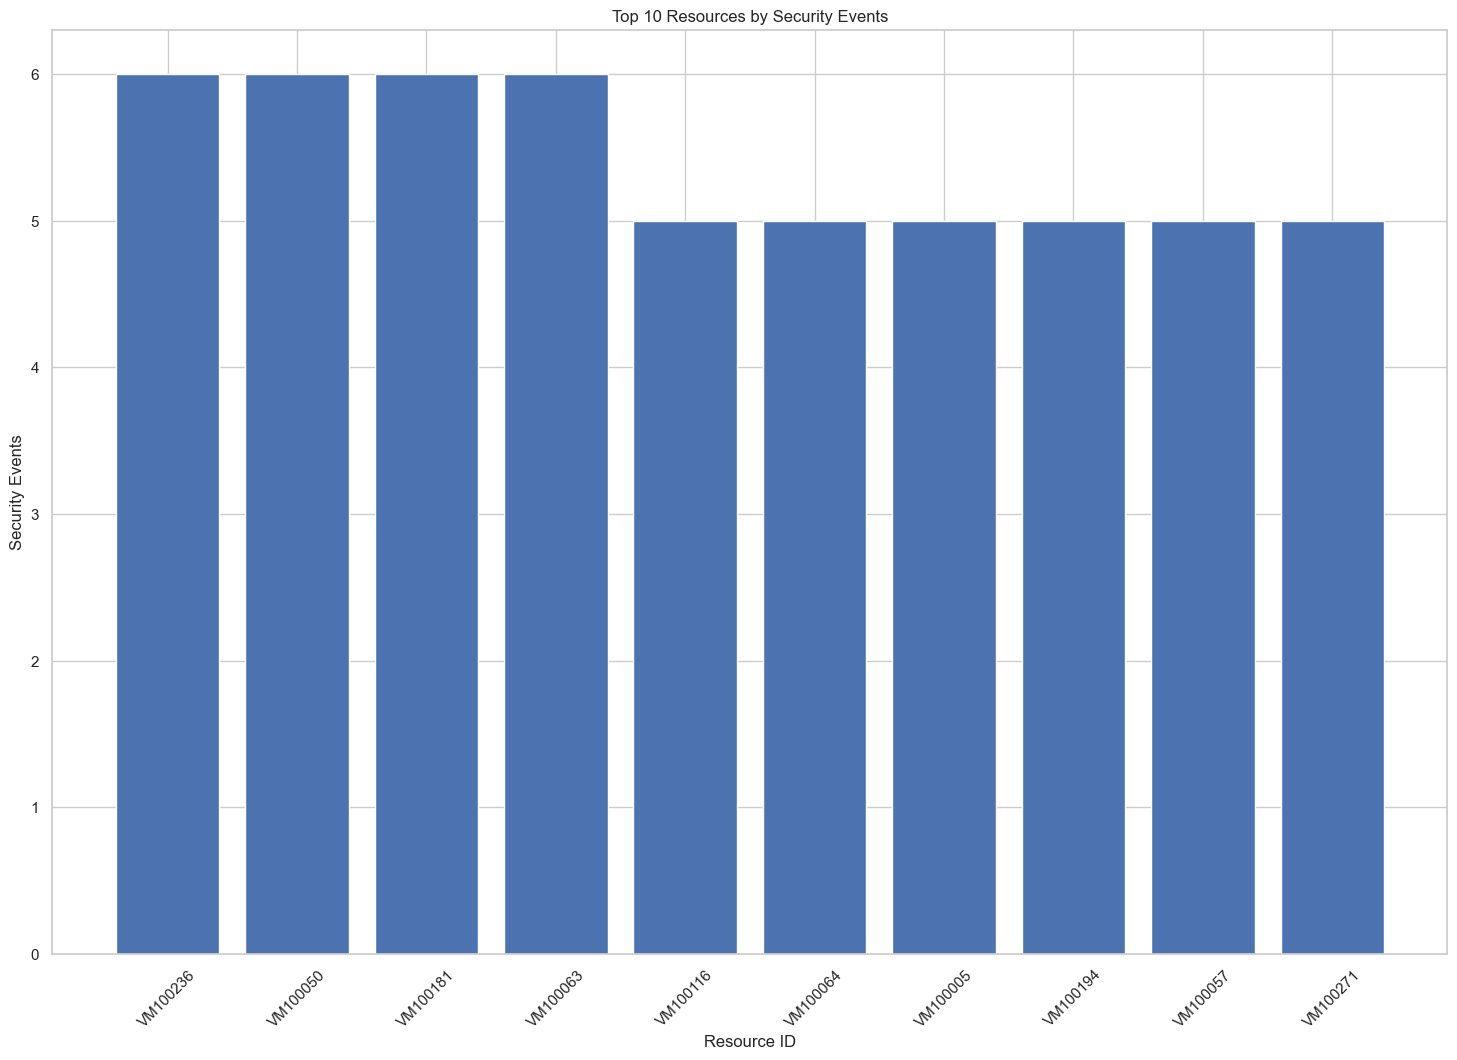

In [201]:
# Security Events by Resource

# Top 10 resources
top10 = security_cost.sort_values(
    by="Security_Events",
    ascending=False
).head(10)

plt.figure(figsize=(18,12))

plt.bar(top10["Resource_ID"], top10["Security_Events"])

plt.title("Top 10 Resources by Security Events")
plt.xlabel("Resource ID")
plt.ylabel("Security Events")

plt.xticks(rotation=45)

plt.show()

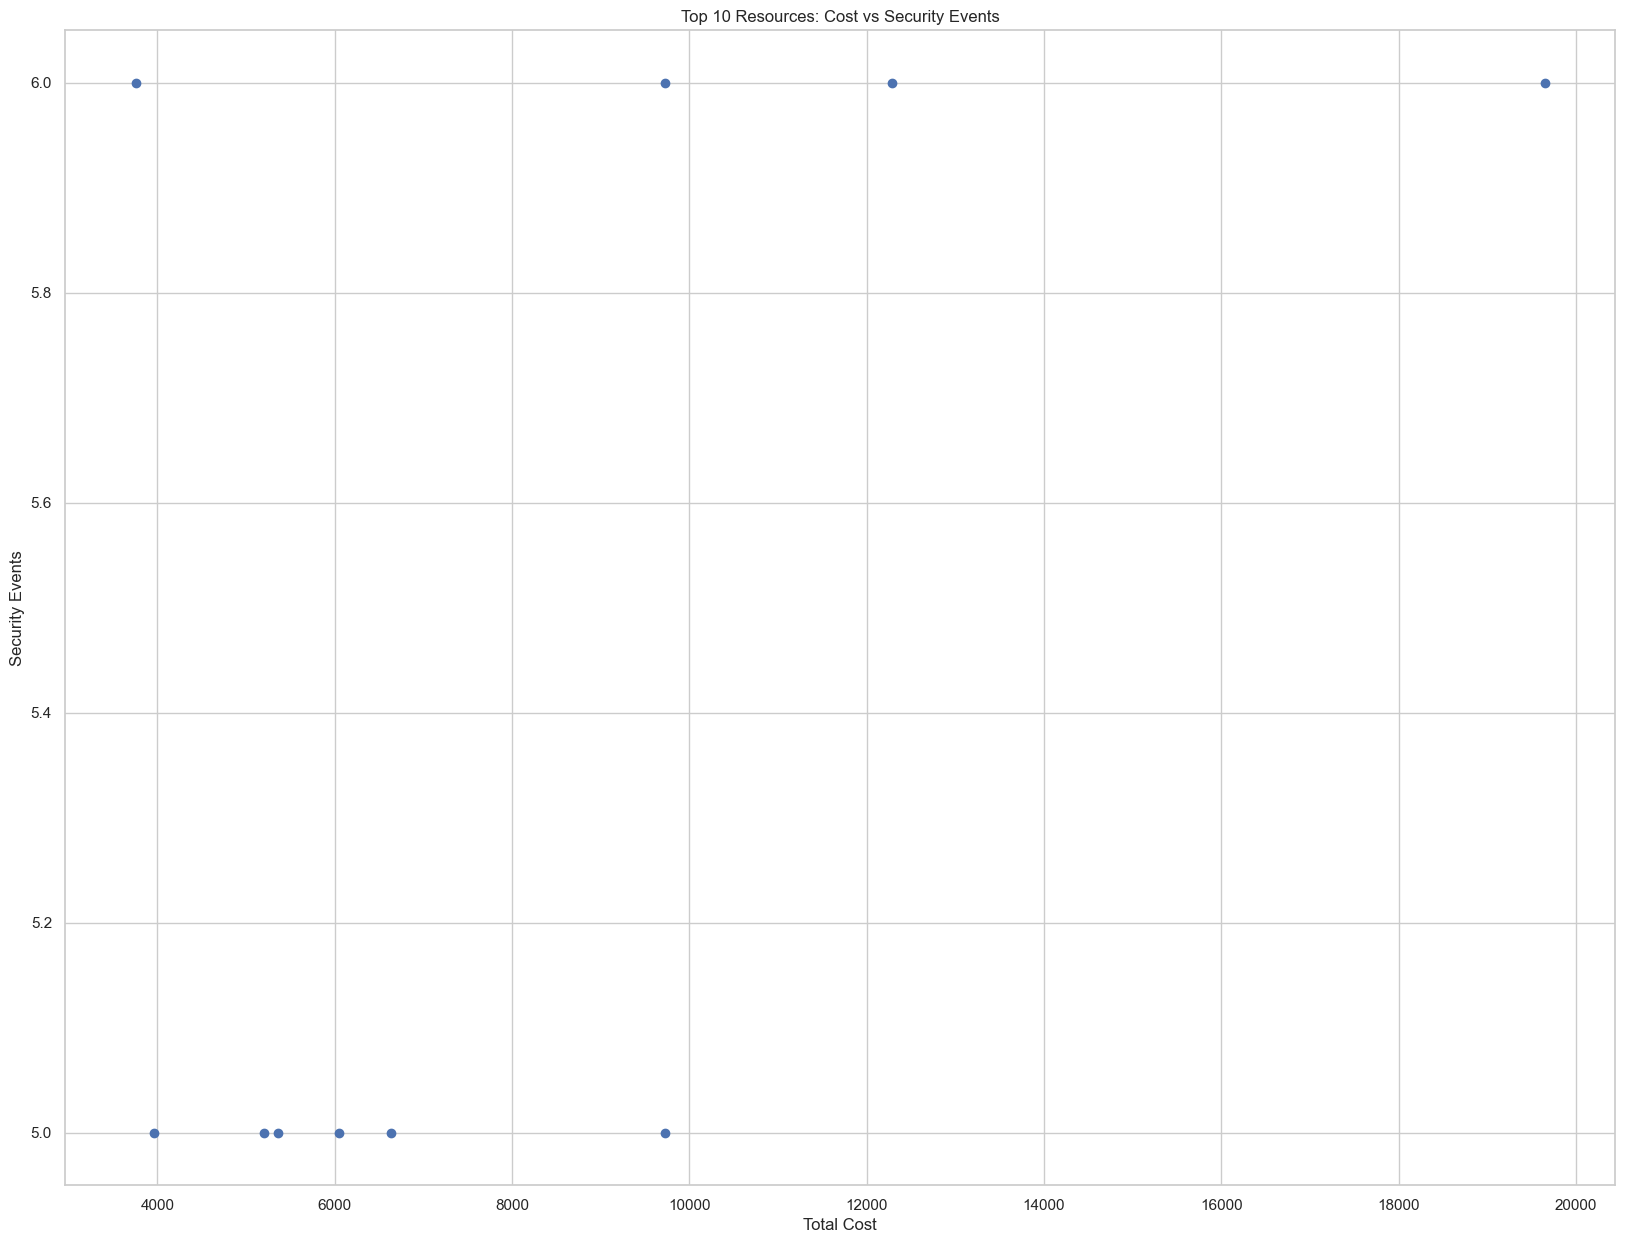

In [202]:
# Cost vs Security Events

# Top 10 resources by Security Events
top10 = security_cost.nlargest(10, "Security_Events")

plt.figure(figsize=(20,15))

plt.scatter(
    top10["Total_Cost"],
    top10["Security_Events"]
)

plt.title("Top 10 Resources: Cost vs Security Events")
plt.xlabel("Total Cost")
plt.ylabel("Security Events")

plt.show()

TF : 20. Public dashboard extracts (privacy‑safe).
====================================================

In [127]:
# Remove duplicate billing records
billing = billing.drop_duplicates(subset="Usage_ID").copy()

# Clean Service names
billing["Service"] = (
    billing["Service"]
    .astype(str)
    .str.strip()
    .str.upper()
)

# Convert numeric columns
billing["Usage"] = pd.to_numeric(
    billing["Usage"],
    errors="coerce"
)

billing["Cost"] = (
    billing["Cost"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.replace("₹", "", regex=False)
    .str.replace("$", "", regex=False)
    .str.strip()
)

billing["Cost"] = pd.to_numeric(
    billing["Cost"],
    errors="coerce"
)


In [128]:
# PUBLIC DASHBOARD DATASET
public_dashboard = (
    billing
    .groupby("Service", as_index=False)
    .agg(
        Total_Usage=("Usage", "sum"),
        Total_Cost=("Cost", "sum")
    )
    .sort_values("Total_Cost", ascending=False)
)

print(public_dashboard)


    Service  Total_Usage  Total_Cost
1  DATABASE      6757512   540600.96
2   NETWORK      6737722   539017.76
3   STORAGE      6267284   501382.72
0   COMPUTE      5482834   438626.72


In [129]:
# EXPORT
public_dashboard.to_csv(
    "Public_Dashboard.csv",
    index=False
)

# TOP SERVICES
top10_service = (
    public_dashboard
    .sort_values(
        "Total_Usage",
        ascending=False
    )
    .head(10)
)


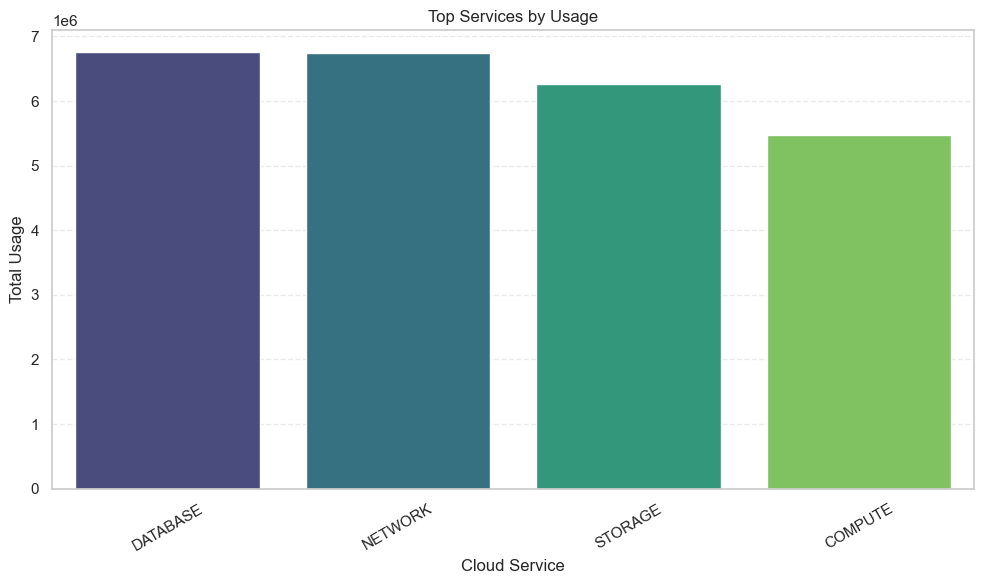

In [130]:
# GRAPH
plt.figure(figsize=(10,6))

sns.barplot(
    data=top10_service,
    x="Service",
    y="Total_Usage",
    hue="Service",
    palette="viridis",
    legend=False
)

plt.title("Top Services by Usage")
plt.xlabel("Cloud Service")
plt.ylabel("Total Usage")

plt.xticks(rotation=30)

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()

plt.show()